In [1]:
# ==== Setup ====
from pathlib import Path
import numpy as np, nibabel as nib, pandas as pd
from numpy.fft import fftn, fftshift
from scipy.ndimage import laplace
from scipy import stats
import matplotlib.pyplot as plt
import json, textwrap, datetime as dt

# Where to write combined outputs for this run
RUN_TAG = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_ROOT = Path(f"./_image_quality_eval_{RUN_TAG}")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# ==== Dataset registry (edit if paths change) ====
BASE = Path("/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global")
DATASETS = {
    # Baselines
    "High-Res (test_hires)" : BASE / "test_hires",
    "Low-Res (test_lores)"  : BASE / "test_lores",

    # Downsampled variants (all mapped to friendly labels)
    "Crude 2×2×5× (backTo1mm)"       : BASE / "test_hires_crude_2x2x5x_backTo1mm",
    "In-Plane 2×2×1mm (backTo1mm)"   : BASE / "test_hires_inplane_2x2x1mm_backTo1mm",
    "Motion (slice jitter)"          : BASE / "test_hires_motion_slicejitter",
    "Reduced SNR (k-space v1)"       : BASE / "test_hires_snr_kspace_v1",
    "Thick slice 1×1×5mm (backTo1mm)": BASE / "test_hires_thickslice_1x1x5mm_backTo1mm",
}

for name, p in DATASETS.items():
    assert p.exists(), f"Missing: {name} -> {p}"

print("Output dir:", OUT_ROOT)
print("Datasets:")
for k,v in DATASETS.items():
    print(" -", k, "->", v)


Output dir: _image_quality_eval_20251112_120355
Datasets:
 - High-Res (test_hires) -> /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/test_hires
 - Low-Res (test_lores) -> /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/test_lores
 - Crude 2×2×5× (backTo1mm) -> /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/test_hires_crude_2x2x5x_backTo1mm
 - In-Plane 2×2×1mm (backTo1mm) -> /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/test_hires_inplane_2x2x1mm_backTo1mm
 - Motion (slice jitter) -> /home/rbielski/ARC/ds004884/derivatives/aggregates/t

In [6]:
def zscore_in_brain(vol: np.ndarray):
    """Z-score only within nonzero voxels; return z-img and boolean mask."""
    m = vol != 0
    out = np.zeros_like(vol, dtype=np.float32)
    if m.any():
        v = vol[m].astype(np.float32)
        mu, sd = v.mean(), v.std() if v.std() > 0 else 1.0
        out[m] = (vol[m] - mu) / sd
    return out, m

# ---- Robust guards for metrics ----
import numpy as np

def estimate_fwhm_gaussian_acf(img: np.ndarray, mask: np.ndarray, shifts=(1,2,3),
                               max_fwhm_mm=50.0, min_pairs=1000) -> float:
    """Return NaN if the Gaussian fit is ill-posed or unphysical."""
    cors = []
    for s in shifts:
        for axis in (0,1,2):
            slicer_f = [slice(None)]*3
            slicer_g = [slice(None)]*3
            slicer_f[axis] = slice(0, -s)
            slicer_g[axis] = slice(s, None)
            f = img[tuple(slicer_f)]; g = img[tuple(slicer_g)]
            m = mask[tuple(slicer_f)] & mask[tuple(slicer_g)]
            if m.sum() < min_pairs:
                continue
            fv = f[m] - f[m].mean(); gv = g[m] - g[m].mean()
            sd = (fv.std() * gv.std())
            if sd <= 1e-8: 
                continue
            r = float((fv*gv).mean() / sd)
            # clamp R into (0,1) where log is meaningful and avoid negative/zero
            r = max(min(r, 0.999), 1e-6)
            cors.append((s, r))
    if not cors:
        return float("nan")

    # average by shift
    bys = {}
    for s, r in cors: bys.setdefault(s, []).append(r)
    s2 = np.array(sorted(bys), dtype=float)**2
    R  = np.array([np.mean(bys[s]) for s in sorted(bys)], dtype=float)

    lnR = np.log(R)
    if not np.all(np.isfinite(lnR)): 
        return float("nan")

    A = np.vstack([np.ones_like(s2), s2]).T
    a, b = np.linalg.lstsq(A, lnR, rcond=None)[0]
    # b should be negative; if slope ~0 or positive, bail
    if not np.isfinite(b) or b >= -1e-6:
        return float("nan")

    sigma = np.sqrt(-1.0/(2.0*b))
    fwhm = 2.355 * sigma

    # reject unphysical outliers (e.g., > 50 mm in 1 mm voxels)
    if not np.isfinite(fwhm) or fwhm <= 0 or fwhm > max_fwhm_mm:
        return float("nan")
    return float(fwhm)

def high_freq_energy_ratio(img: np.ndarray, mask: np.ndarray, cutoff=0.25) -> float:
    """Return NaN if total spectral power is ~0; otherwise regular HFE."""
    from numpy.fft import fftn, fftshift
    vol = np.zeros_like(img, dtype=np.float32)
    vol[mask] = img[mask]
    F = fftshift(fftn(vol))
    P = (np.abs(F)**2).astype(np.float64)
    tot = P.sum()
    if not np.isfinite(tot) or tot <= 1e-12:
        return float("nan")

    nx, ny, nz = img.shape
    cx, cy, cz = (np.array(img.shape)-1)/2.0
    x = np.arange(nx) - cx
    y = np.arange(ny) - cy
    z = np.arange(nz) - cz
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    rx = np.abs(X) / (nx/2.0); ry = np.abs(Y) / (ny/2.0); rz = np.abs(Z) / (nz/2.0)
    r = np.sqrt((rx**2 + ry**2 + rz**2)/3.0)

    hf = P[r >= cutoff].sum()
    return float(hf / (tot + 1e-12))

def laplacian_variance(img: np.ndarray, mask: np.ndarray) -> float:
    """Variance of Laplacian on the z-scored image; larger ⇒ sharper."""
    L = laplace(img)
    return float(L[mask].var())


In [23]:
def scan_dir(dir_path: Path, dataset_name: str):
    out = []
    files = sorted([*dir_path.glob("*.nii"), *dir_path.glob("*.nii.gz")])
    for p in files:
        try:
            img = nib.load(str(p)).get_fdata().astype(np.float32)
            zimg, m = zscore_in_brain(img)
            if m.sum() < 5000:
                continue
            fwhm = estimate_fwhm_gaussian_acf(zimg, m)
            hfe  = high_freq_energy_ratio(zimg, m, cutoff=0.25)
            lvar = laplacian_variance(zimg, m)
            out.append(dict(dataset=dataset_name, path=str(p), fwhm_mm=fwhm,
                            hi_freq_energy=hfe, lap_var=lvar))
        except Exception as e:
            out.append(dict(dataset=dataset_name, path=str(p),
                            fwhm_mm=np.nan, hi_freq_energy=np.nan, lap_var=np.nan))
    return out

# Run across all datasets
all_rows = []
for name, path in DATASETS.items():
    rows = scan_dir(path, name)
    print(f"{name}: {len(rows)} files")
    all_rows.extend(rows)

df = pd.DataFrame(all_rows)
CSV_PATH = OUT_ROOT / "effective_resolution_metrics_ALL.csv"
df.to_csv(CSV_PATH, index=False)
print("Wrote:", CSV_PATH)

# quick peek
df


High-Res (test_hires): 236 files
Low-Res (test_lores): 335 files
Crude 2×2×5× (backTo1mm): 236 files
In-Plane 2×2×1mm (backTo1mm): 236 files
Motion (slice jitter): 236 files
Reduced SNR (k-space v1): 236 files
Thick slice 1×1×5mm (backTo1mm): 236 files
Wrote: _image_quality_eval_20251112_120355/effective_resolution_metrics_ALL.csv


,dataset,path,fwhm_mm,hi_freq_energy,lap_var
0,High-Res (test_hires),/home/rbielski/ARC/ds004884/derivatives/aggreg...,9.377495,0.131998,2.646504
1,High-Res (test_hires),/home/rbielski/ARC/ds004884/derivatives/aggreg...,NaN,NaN,0.000000
2,High-Res (test_hires),/home/rbielski/ARC/ds004884/derivatives/aggreg...,8.876189,0.117649,2.148141
3,High-Res (test_hires),/home/rbielski/ARC/ds004884/derivatives/aggreg...,NaN,NaN,0.000000
4,High-Res (test_hires),/home/rbielski/ARC/ds004884/derivatives/aggreg...,9.783152,0.125409,2.399140
...,...,...,...,...,...
1746,Thick slice 1×1×5mm (backTo1mm),/home/rbielski/ARC/ds004884/derivatives/aggreg...,10.466881,0.076720,0.850490
1747,Thick slice 1×1×5mm (backTo1mm),/home/rbielski/ARC/ds004884/derivatives/aggreg...,NaN,NaN,0.000000
1748,Thick slice 1×1×5mm (backTo1mm),/home/rbielski/ARC/ds004884/derivatives/aggreg...,10.575639,0.063367,0.696009
1749,Thick slice 1×1×5mm (backTo1mm),/home/rbielski/ARC/ds004884/derivatives/aggreg...,NaN,NaN,0.000000


In [8]:
def summarize_df(df: pd.DataFrame, by="dataset"):
    lines = []
    for dname in sorted(df[by].unique()):
        d = df[df[by]==dname]
        lines.append(f"\n=== {dname} — N={len(d)} ===")
        for col, desc in [
            ("fwhm_mm", "FWHM blur (mm, smaller=sharper)"),
            ("hi_freq_energy", "High-freq energy fraction (larger=sharper)"),
            ("lap_var", "Variance of Laplacian (larger=sharper)")
        ]:
            v = d[col].dropna().to_numpy()
            if v.size == 0:
                lines.append(f"  {desc}: (no data)")
                continue
            p10, p50, p90 = np.percentile(v, [10,50,90])
            lines.append(f"  {desc}: p10/50/90 = {p10:.3f} / {p50:.3f} / {p90:.3f} | mean±sd = {v.mean():.3f}±{v.std():.3f}")
    return "\n".join(lines)

summary_text = summarize_df(df)
print(summary_text)

(OUT_ROOT / "summary_percentiles.txt").write_text(summary_text)



=== Crude 2×2×5× (backTo1mm) — N=236 ===
  FWHM blur (mm, smaller=sharper): p10/50/90 = 7.661 / 8.640 / 9.751 | mean±sd = 8.641±0.798
  High-freq energy fraction (larger=sharper): p10/50/90 = 0.133 / 0.160 / 0.187 | mean±sd = 0.160±0.023
  Variance of Laplacian (larger=sharper): p10/50/90 = 0.000 / 1.841 / 2.446 | mean±sd = 1.269±1.097

=== High-Res (test_hires) — N=236 ===
  FWHM blur (mm, smaller=sharper): p10/50/90 = 6.763 / 7.834 / 8.894 | mean±sd = 7.790±0.822
  High-freq energy fraction (larger=sharper): p10/50/90 = 0.080 / 0.123 / 0.160 | mean±sd = 0.122±0.028
  Variance of Laplacian (larger=sharper): p10/50/90 = 0.000 / 1.416 / 2.563 | mean±sd = 1.181±1.080

=== In-Plane 2×2×1mm (backTo1mm) — N=236 ===
  FWHM blur (mm, smaller=sharper): p10/50/90 = 9.846 / 10.827 / 12.764 | mean±sd = 11.131±1.160
  High-freq energy fraction (larger=sharper): p10/50/90 = 0.056 / 0.063 / 0.073 | mean±sd = 0.064±0.007
  Variance of Laplacian (larger=sharper): p10/50/90 = 0.000 / 0.736 / 0.916 | m

2385

In [9]:
BASE_HI = "High-Res (test_hires)"
BASE_LO = "Low-Res (test_lores)"

from scipy import stats

def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    x = x[np.isfinite(x)]; y = y[np.isfinite(y)]
    if x.size==0 or y.size==0: return np.nan
    xy = np.concatenate([x,y])
    ranks = stats.rankdata(xy)
    rx = ranks[:len(x)]
    U = np.sum(rx) - len(x)*(len(x)+1)/2
    delta = (2*U)/(len(x)*len(y)) - 1
    return float(delta)

def bootstrap_ci(a, stat=np.mean, nboot=2000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    a = np.asarray(a); a = a[np.isfinite(a)]
    if a.size==0: return np.nan, (np.nan, np.nan)
    boots = [stat(rng.choice(a, size=a.size, replace=True)) for _ in range(nboot)]
    lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
    return float(stat(a)), (float(lo), float(hi))

def hodges_lehmann_shift(x, y):
    """Robust median difference estimator (HL)."""
    x = np.asarray(x); y = np.asarray(y)
    x = x[np.isfinite(x)]; y = y[np.isfinite(y)]
    if x.size==0 or y.size==0: return np.nan
    diffs = (y.reshape(-1,1) - x.reshape(1,-1)).ravel()
    return float(np.median(diffs))

def compare_against(df, base_name, metrics=("fwhm_mm","hi_freq_energy","lap_var")):
    rows = []
    base = df[df["dataset"]==base_name]
    for dname in df["dataset"].unique():
        if dname == base_name: 
            continue
        cur = df[df["dataset"]==dname]
        for col in metrics:
            x = base[col].to_numpy()
            y = cur[col].to_numpy()
            x_clean = x[np.isfinite(x)]
            y_clean = y[np.isfinite(y)]

            if x_clean.size<3 or y_clean.size<3:
                U = p = np.nan
            else:
                U, p = stats.mannwhitneyu(x_clean, y_clean, alternative="two-sided")

            delta = cliffs_delta(y_clean, x_clean)  # positive => group > base
            mu_base, ci_base = bootstrap_ci(x_clean, stat=np.mean)
            mu_group, ci_group = bootstrap_ci(y_clean, stat=np.mean)
            pct = 100.0 * (mu_group - mu_base) / abs(mu_base) if np.isfinite(mu_base) and mu_base!=0 else np.nan
            # also report robust median and HL shift
            med_base, _ = bootstrap_ci(x_clean, stat=np.median)
            med_group, _ = bootstrap_ci(y_clean, stat=np.median)
            hl = hodges_lehmann_shift(x_clean, y_clean)

            rows.append(dict(
                compare_to=base_name,
                dataset=dname,
                metric=col,
                U=U, p=p,
                cliffs_delta=delta,
                mean_base=mu_base, mean_group=mu_group,
                ci_lo=ci_group[0], ci_hi=ci_group[1],
                pct_vs_base=pct,
                median_base=med_base, median_group=med_group,
                HL_shift=hl,
                n_base=int(x_clean.size), n_group=int(y_clean.size)
            ))
    return pd.DataFrame(rows)

stats_vs_hi = compare_against(df, "High-Res (test_hires)")
stats_vs_lo = compare_against(df, "Low-Res (test_lores)")
display(stats_vs_hi.sort_values(["metric","dataset"]))
display(stats_vs_lo.sort_values(["metric","dataset"]))


display(stats_vs_hi.sort_values(["metric","dataset"]))
display(stats_vs_lo.sort_values(["metric","dataset"]))


,compare_to,dataset,metric,U,p,cliffs_delta,mean_base,mean_group,ci_lo,ci_hi,pct_vs_base,median_base,median_group,HL_shift,n_base,n_group
3,High-Res (test_hires),Crude 2×2×5× (backTo1mm),fwhm_mm,4473.0,2.649794e-14,0.530246,7.789888,8.641022,8.509285,8.769501,10.926133,7.833809,8.640489,0.850470,138,138
6,High-Res (test_hires),In-Plane 2×2×1mm (backTo1mm),fwhm_mm,21.0,1.440290e-46,0.997795,7.789888,11.131369,10.943391,11.329087,42.895104,7.833809,10.826888,3.200204,138,138
0,High-Res (test_hires),Low-Res (test_lores),fwhm_mm,6123.0,7.582266e-18,0.551823,7.789888,8.840685,8.692872,9.001120,13.489238,7.833809,8.674507,0.963688,138,198
9,High-Res (test_hires),Motion (slice jitter),fwhm_mm,5165.0,5.009081e-11,0.457572,7.789888,8.581547,8.425283,8.737193,10.162645,7.833809,8.538300,0.764285,138,138
12,High-Res (test_hires),Reduced SNR (k-space v1),fwhm_mm,0.0,9.123871e-47,1.000000,7.789888,15.820815,15.580210,16.067024,103.094251,7.833809,15.538969,7.862188,138,138
15,High-Res (test_hires),Thick slice 1×1×5mm (backTo1mm),fwhm_mm,20.0,1.409348e-46,0.997900,7.789888,11.484414,11.262521,11.699581,47.427197,7.833809,11.114100,3.538948,138,138
4,High-Res (test_hires),Crude 2×2×5× (backTo1mm),hi_freq_energy,2746.0,1.628318e-24,0.711615,0.121961,0.160036,0.156240,0.163830,31.218518,0.123184,0.159604,0.037020,138,138
7,High-Res (test_hires),In-Plane 2×2×1mm (backTo1mm),hi_freq_energy,18565.0,2.370288e-42,-0.949695,0.121961,0.064036,0.062986,0.065119,-47.495034,0.123184,0.063297,-0.058217,138,138
1,High-Res (test_hires),Low-Res (test_lores),hi_freq_energy,24100.0,9.867189e-33,-0.764017,0.121961,0.075901,0.072161,0.079422,-37.766156,0.123184,0.074141,-0.046903,138,198
10,High-Res (test_hires),Motion (slice jitter),hi_freq_energy,261.0,2.475184e-44,0.972590,0.121961,0.205475,0.200961,0.210150,68.475336,0.123184,0.200553,0.081699,138,138


,compare_to,dataset,metric,U,p,cliffs_delta,mean_base,mean_group,ci_lo,ci_hi,pct_vs_base,median_base,median_group,HL_shift,n_base,n_group
3,Low-Res (test_lores),Crude 2×2×5× (backTo1mm),fwhm_mm,14653.0,2.581697e-01,-0.072537,8.840685,8.641022,8.509285,8.769501,-2.258457,8.674507,8.640489,-0.117197,198,138
0,Low-Res (test_lores),High-Res (test_hires),fwhm_mm,21201.0,7.582266e-18,-0.551823,8.840685,7.789888,7.657473,7.925918,-11.885918,8.674507,7.833809,-0.963688,198,138
6,Low-Res (test_lores),In-Plane 2×2×1mm (backTo1mm),fwhm_mm,1914.0,5.239606e-41,0.859903,8.840685,11.131369,10.943391,11.329087,25.910710,8.674507,10.826888,2.221367,198,138
9,Low-Res (test_lores),Motion (slice jitter),fwhm_mm,15252.0,6.959622e-02,-0.116381,8.840685,8.581547,8.425283,8.737193,-2.931197,8.674507,8.538300,-0.205184,198,138
12,Low-Res (test_lores),Reduced SNR (k-space v1),fwhm_mm,0.0,7.799457e-55,1.000000,8.840685,15.820815,15.580210,16.067024,78.954635,8.674507,15.538969,6.877099,198,138
15,Low-Res (test_lores),Thick slice 1×1×5mm (backTo1mm),fwhm_mm,1539.0,1.488461e-43,0.887352,8.840685,11.484414,11.262521,11.699581,29.904121,8.674507,11.114100,2.552902,198,138
4,Low-Res (test_lores),Crude 2×2×5× (backTo1mm),hi_freq_energy,233.0,4.849071e-53,0.982945,0.075901,0.160036,0.156240,0.163830,110.847523,0.074141,0.159604,0.084467,198,138
1,Low-Res (test_lores),High-Res (test_hires),hi_freq_energy,3224.0,9.867189e-33,0.764017,0.075901,0.121961,0.117176,0.126482,60.684274,0.074141,0.123184,0.046903,198,138
7,Low-Res (test_lores),In-Plane 2×2×1mm (backTo1mm),hi_freq_energy,17289.0,3.474375e-05,-0.265481,0.075901,0.064036,0.062986,0.065119,-15.632776,0.074141,0.063297,-0.009937,198,138
10,Low-Res (test_lores),Motion (slice jitter),hi_freq_energy,5.0,8.528543e-55,0.999634,0.075901,0.205475,0.200961,0.210150,170.713371,0.074141,0.200553,0.128915,198,138


,compare_to,dataset,metric,U,p,cliffs_delta,mean_base,mean_group,ci_lo,ci_hi,pct_vs_base,median_base,median_group,HL_shift,n_base,n_group
3,High-Res (test_hires),Crude 2×2×5× (backTo1mm),fwhm_mm,4473.0,2.649794e-14,0.530246,7.789888,8.641022,8.509285,8.769501,10.926133,7.833809,8.640489,0.850470,138,138
6,High-Res (test_hires),In-Plane 2×2×1mm (backTo1mm),fwhm_mm,21.0,1.440290e-46,0.997795,7.789888,11.131369,10.943391,11.329087,42.895104,7.833809,10.826888,3.200204,138,138
0,High-Res (test_hires),Low-Res (test_lores),fwhm_mm,6123.0,7.582266e-18,0.551823,7.789888,8.840685,8.692872,9.001120,13.489238,7.833809,8.674507,0.963688,138,198
9,High-Res (test_hires),Motion (slice jitter),fwhm_mm,5165.0,5.009081e-11,0.457572,7.789888,8.581547,8.425283,8.737193,10.162645,7.833809,8.538300,0.764285,138,138
12,High-Res (test_hires),Reduced SNR (k-space v1),fwhm_mm,0.0,9.123871e-47,1.000000,7.789888,15.820815,15.580210,16.067024,103.094251,7.833809,15.538969,7.862188,138,138
15,High-Res (test_hires),Thick slice 1×1×5mm (backTo1mm),fwhm_mm,20.0,1.409348e-46,0.997900,7.789888,11.484414,11.262521,11.699581,47.427197,7.833809,11.114100,3.538948,138,138
4,High-Res (test_hires),Crude 2×2×5× (backTo1mm),hi_freq_energy,2746.0,1.628318e-24,0.711615,0.121961,0.160036,0.156240,0.163830,31.218518,0.123184,0.159604,0.037020,138,138
7,High-Res (test_hires),In-Plane 2×2×1mm (backTo1mm),hi_freq_energy,18565.0,2.370288e-42,-0.949695,0.121961,0.064036,0.062986,0.065119,-47.495034,0.123184,0.063297,-0.058217,138,138
1,High-Res (test_hires),Low-Res (test_lores),hi_freq_energy,24100.0,9.867189e-33,-0.764017,0.121961,0.075901,0.072161,0.079422,-37.766156,0.123184,0.074141,-0.046903,138,198
10,High-Res (test_hires),Motion (slice jitter),hi_freq_energy,261.0,2.475184e-44,0.972590,0.121961,0.205475,0.200961,0.210150,68.475336,0.123184,0.200553,0.081699,138,138


,compare_to,dataset,metric,U,p,cliffs_delta,mean_base,mean_group,ci_lo,ci_hi,pct_vs_base,median_base,median_group,HL_shift,n_base,n_group
3,Low-Res (test_lores),Crude 2×2×5× (backTo1mm),fwhm_mm,14653.0,2.581697e-01,-0.072537,8.840685,8.641022,8.509285,8.769501,-2.258457,8.674507,8.640489,-0.117197,198,138
0,Low-Res (test_lores),High-Res (test_hires),fwhm_mm,21201.0,7.582266e-18,-0.551823,8.840685,7.789888,7.657473,7.925918,-11.885918,8.674507,7.833809,-0.963688,198,138
6,Low-Res (test_lores),In-Plane 2×2×1mm (backTo1mm),fwhm_mm,1914.0,5.239606e-41,0.859903,8.840685,11.131369,10.943391,11.329087,25.910710,8.674507,10.826888,2.221367,198,138
9,Low-Res (test_lores),Motion (slice jitter),fwhm_mm,15252.0,6.959622e-02,-0.116381,8.840685,8.581547,8.425283,8.737193,-2.931197,8.674507,8.538300,-0.205184,198,138
12,Low-Res (test_lores),Reduced SNR (k-space v1),fwhm_mm,0.0,7.799457e-55,1.000000,8.840685,15.820815,15.580210,16.067024,78.954635,8.674507,15.538969,6.877099,198,138
15,Low-Res (test_lores),Thick slice 1×1×5mm (backTo1mm),fwhm_mm,1539.0,1.488461e-43,0.887352,8.840685,11.484414,11.262521,11.699581,29.904121,8.674507,11.114100,2.552902,198,138
4,Low-Res (test_lores),Crude 2×2×5× (backTo1mm),hi_freq_energy,233.0,4.849071e-53,0.982945,0.075901,0.160036,0.156240,0.163830,110.847523,0.074141,0.159604,0.084467,198,138
1,Low-Res (test_lores),High-Res (test_hires),hi_freq_energy,3224.0,9.867189e-33,0.764017,0.075901,0.121961,0.117176,0.126482,60.684274,0.074141,0.123184,0.046903,198,138
7,Low-Res (test_lores),In-Plane 2×2×1mm (backTo1mm),hi_freq_energy,17289.0,3.474375e-05,-0.265481,0.075901,0.064036,0.062986,0.065119,-15.632776,0.074141,0.063297,-0.009937,198,138
10,Low-Res (test_lores),Motion (slice jitter),hi_freq_energy,5.0,8.528543e-55,0.999634,0.075901,0.205475,0.200961,0.210150,170.713371,0.074141,0.200553,0.128915,198,138


/tmp/ipykernel_2056658/4192611675.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[d.replace(" (","\n(") for d in order], showfliers=False)


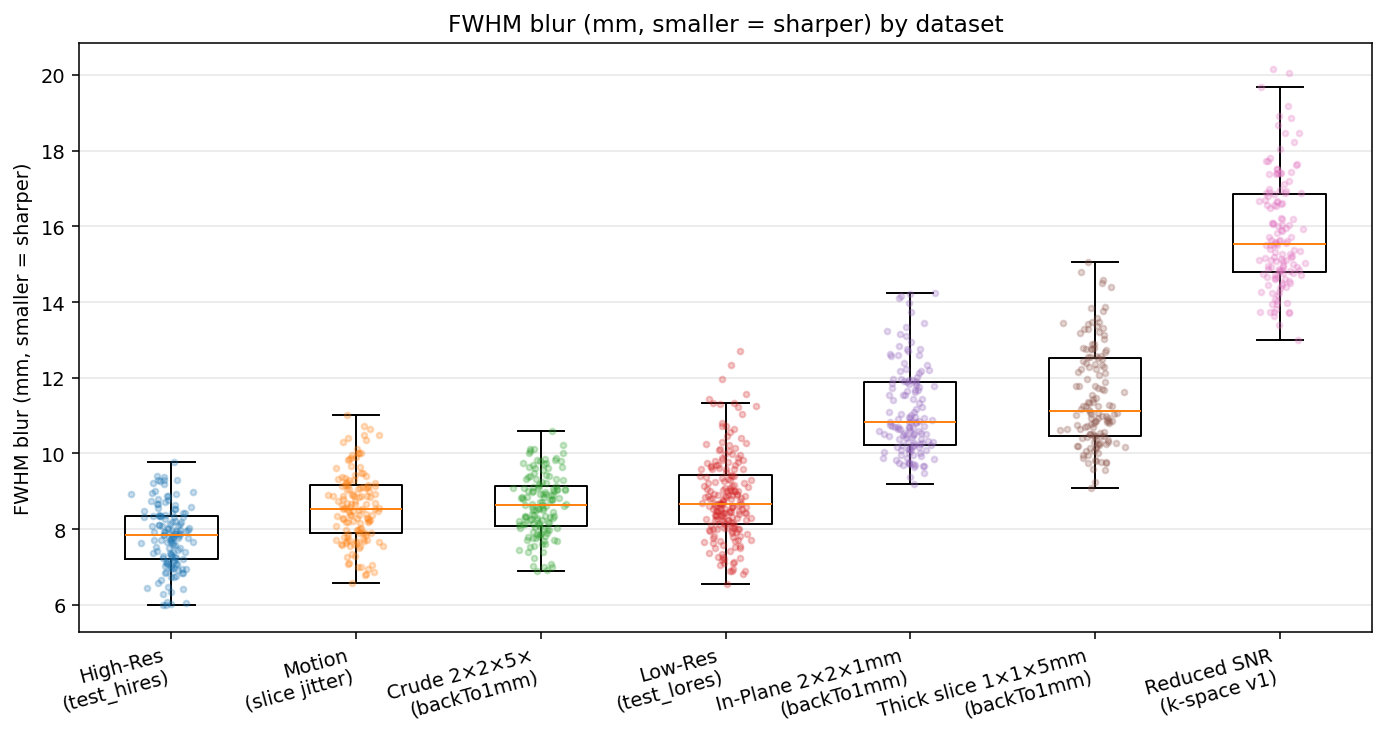

Saved _image_quality_eval_20251112_120355/box_fwhm.png


/tmp/ipykernel_2056658/4192611675.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[d.replace(" (","\n(") for d in order], showfliers=False)


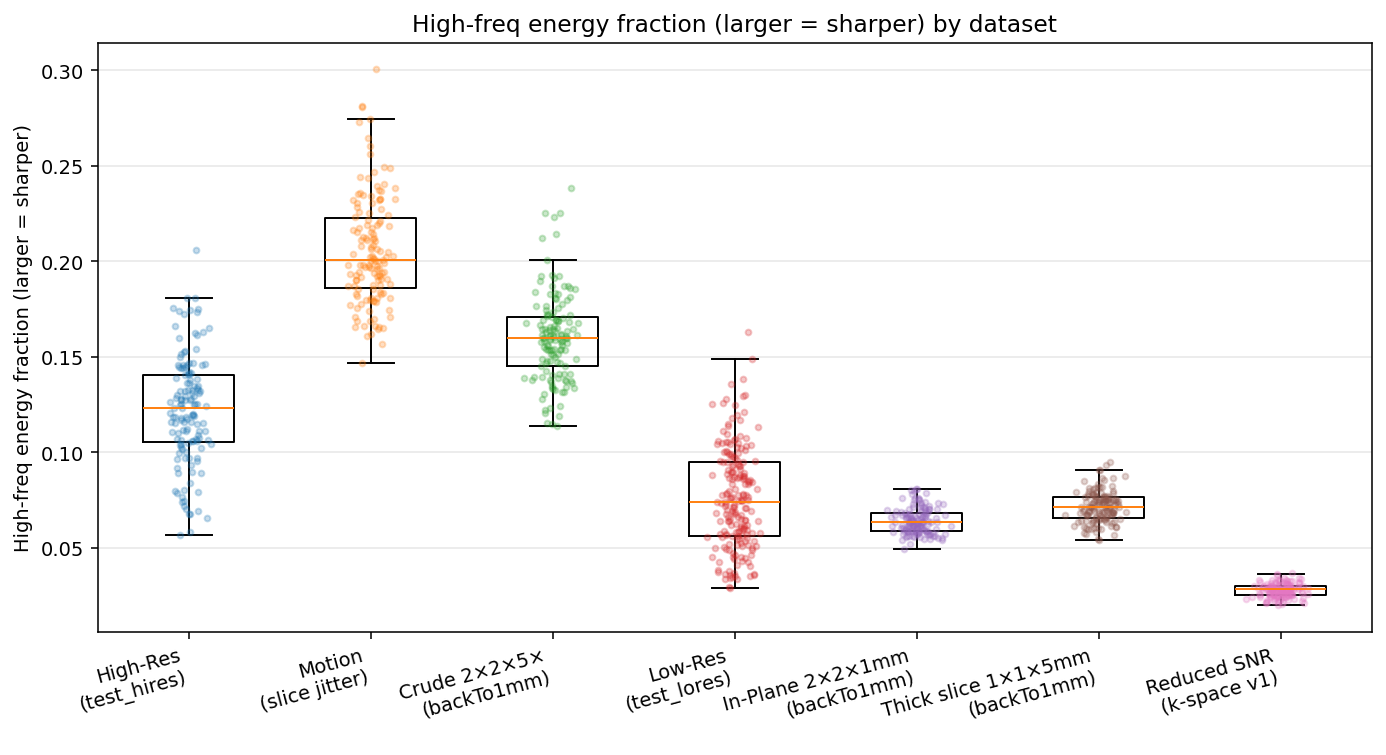

Saved _image_quality_eval_20251112_120355/box_hfe.png


/tmp/ipykernel_2056658/4192611675.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[d.replace(" (","\n(") for d in order], showfliers=False)


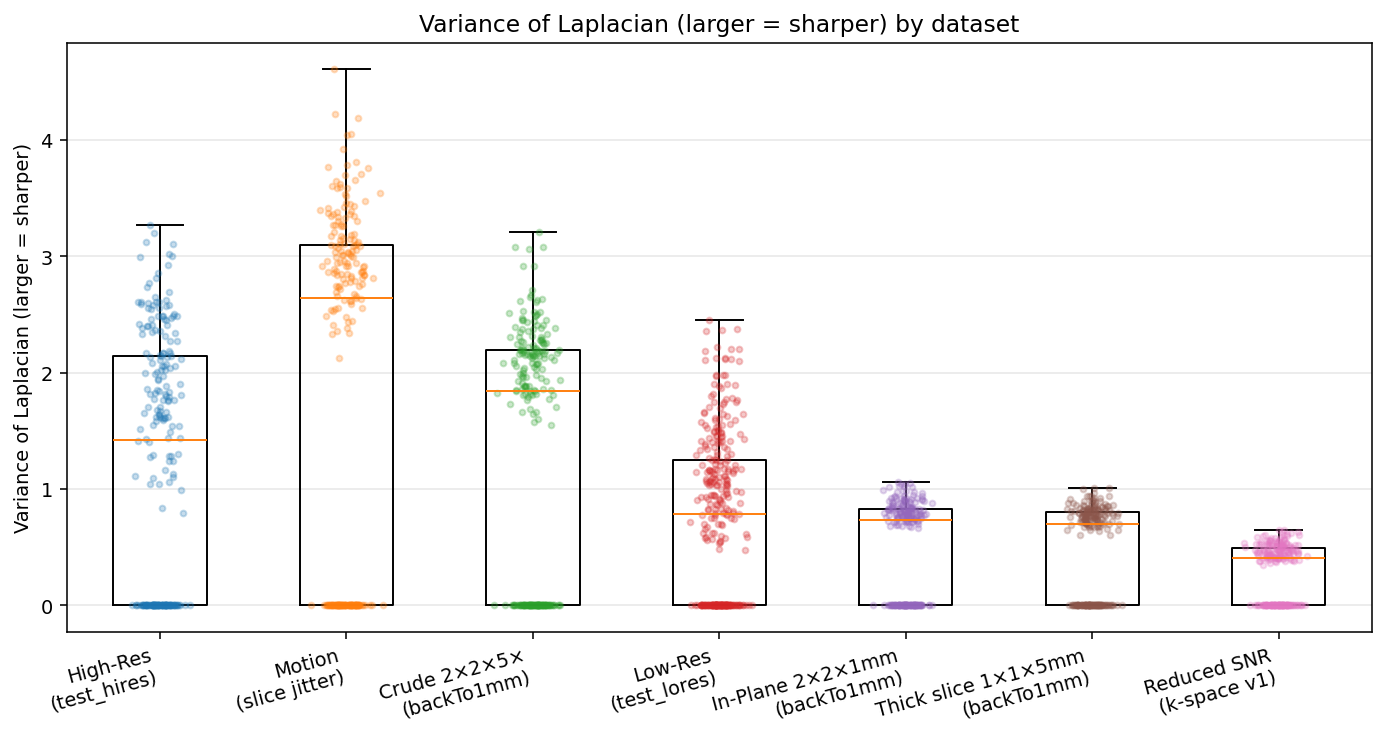

Saved _image_quality_eval_20251112_120355/box_lapvar.png


In [10]:
# consistent order: sort datasets by mean FWHM ascending (sharper first)
order = (df.groupby("dataset")["fwhm_mm"]
           .mean().sort_values(ascending=True).index.tolist())

def box_jitter(df, metric, ylabel, fname):
    fig = plt.figure(figsize=(10,5.5), dpi=140)
    ax = fig.add_subplot(111)
    data = [df[df["dataset"]==d][metric].dropna().values for d in order]
    ax.boxplot(data, labels=[d.replace(" (","\n(") for d in order], showfliers=False)
    # jitter
    for i, d in enumerate(order, start=1):
        v = df[df["dataset"]==d][metric].dropna().values
        if v.size==0: continue
        x = np.random.normal(i, 0.06, size=v.size)
        ax.plot(x, v, "o", alpha=0.25, markersize=3)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by dataset")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    p = OUT_ROOT/f"box_{fname}.png"
    plt.savefig(p, dpi=200); plt.show()
    print("Saved", p)

box_jitter(df, "fwhm_mm", "FWHM blur (mm, smaller = sharper)", "fwhm")
box_jitter(df, "hi_freq_energy", "High-freq energy fraction (larger = sharper)", "hfe")
box_jitter(df, "lap_var", "Variance of Laplacian (larger = sharper)", "lapvar")


In [14]:
# ==== Display names, order, and colors ====
label_map = {
    "High-Res (test_hires)"              : "Higher Resolution",
    "Low-Res (test_lores)"               : "Lower Resolution",
    "Crude 2×2×5× (backTo1mm)"           : "Crude Downsample",
    "Thick slice 1×1×5mm (backTo1mm)"    : "Thick Slices",
    "In-Plane 2×2×1mm (backTo1mm)"       : "In-plane Coarsening",
    "Reduced SNR (k-space v1)"           : "Reduced SNR",
    "Motion (slice jitter)"              : "Rigid Jitter",
}

order_display = [
    "Higher Resolution",
    "Lower Resolution",
    "Crude Downsample",
    "Thick Slices",
    "In-plane Coarsening",
    "Reduced SNR",
    "Rigid Jitter",
]

# named colors (matplotlib) — using clear picks
color_map = {
    "Higher Resolution"   : "blue",
    "Lower Resolution"    : "red",
    "Crude Downsample"    : "green",
    "Thick Slices"        : "orange",
    "In-plane Coarsening" : "lightblue",  # you asked "light blue"
    "Reduced SNR"         : "purple",
    "Rigid Jitter"        : "pink",
}

# Make a display-labelled copy of df
df_disp = df.copy()
df_disp["display"] = df_disp["dataset"].map(label_map)
# keep only rows that mapped (the seven groups)
df_disp = df_disp[ df_disp["display"].isin(order_display) ].copy()

# If some groups are missing in the current df, keep order but drop missing
order_present = [d for d in order_display if d in df_disp["display"].unique()]


/tmp/ipykernel_2056658/518304981.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


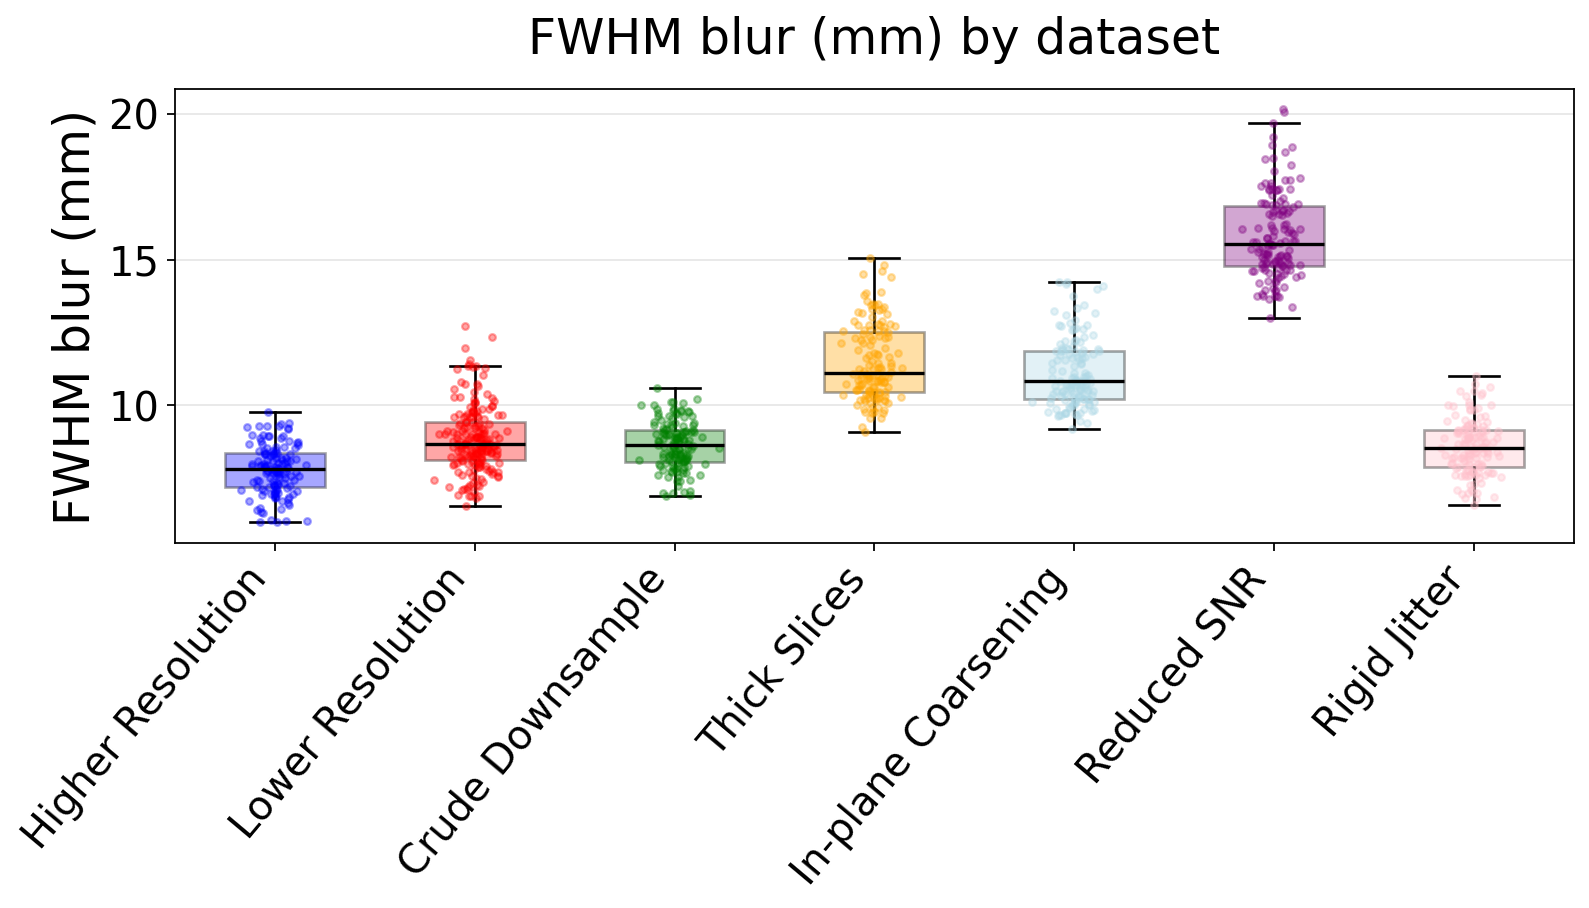

Saved _image_quality_eval_20251112_120355/box_fwhm_styled.png


/tmp/ipykernel_2056658/518304981.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


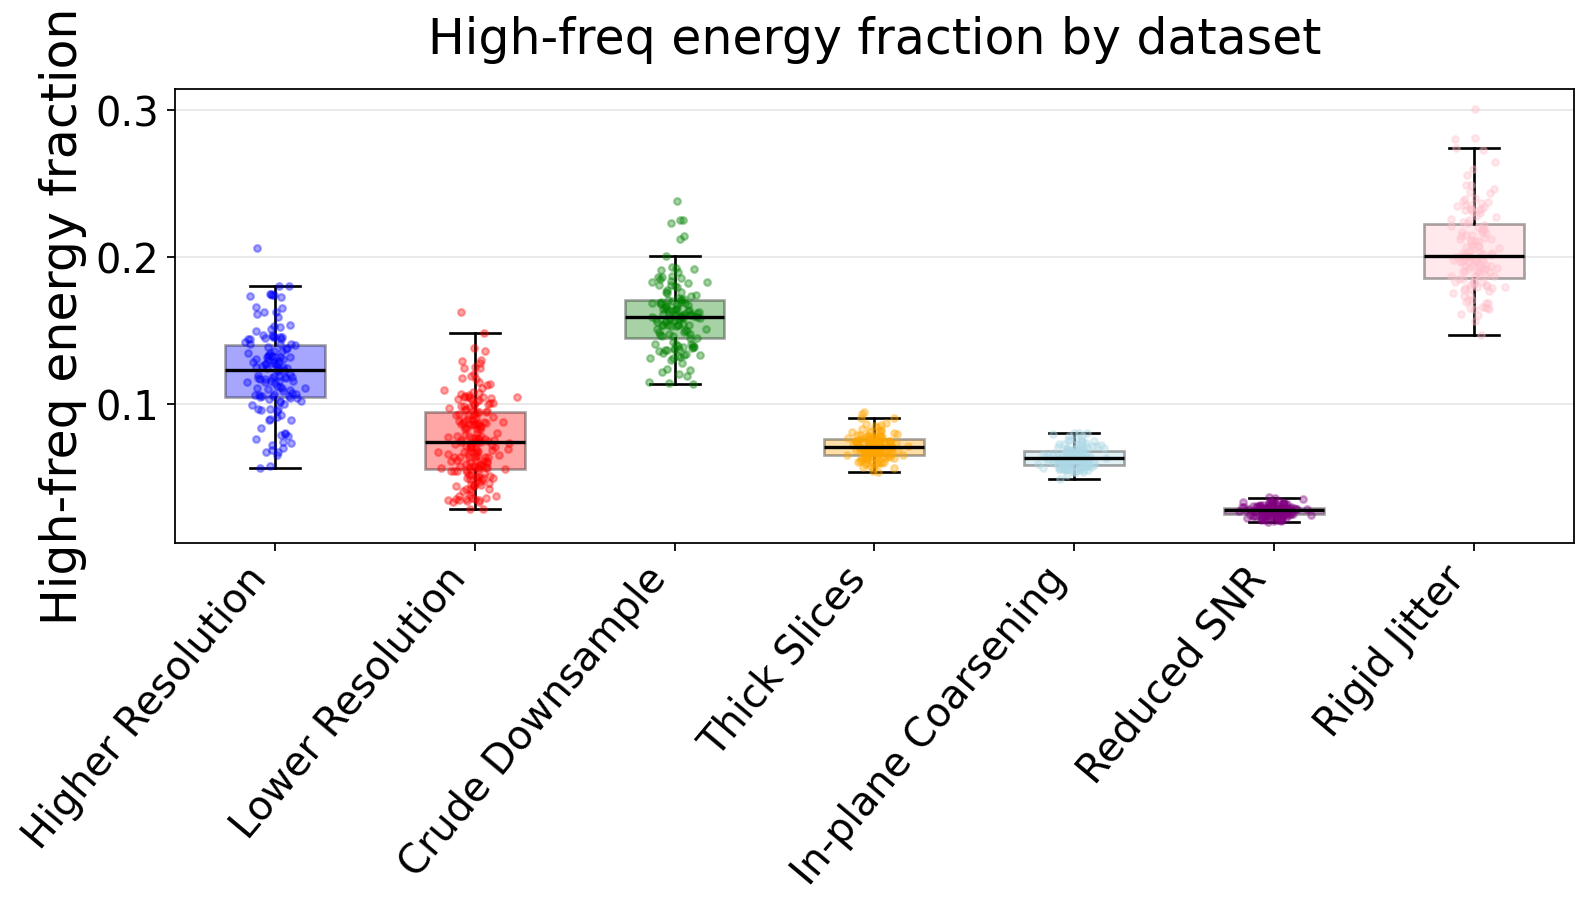

Saved _image_quality_eval_20251112_120355/box_hfe_styled.png


/tmp/ipykernel_2056658/518304981.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


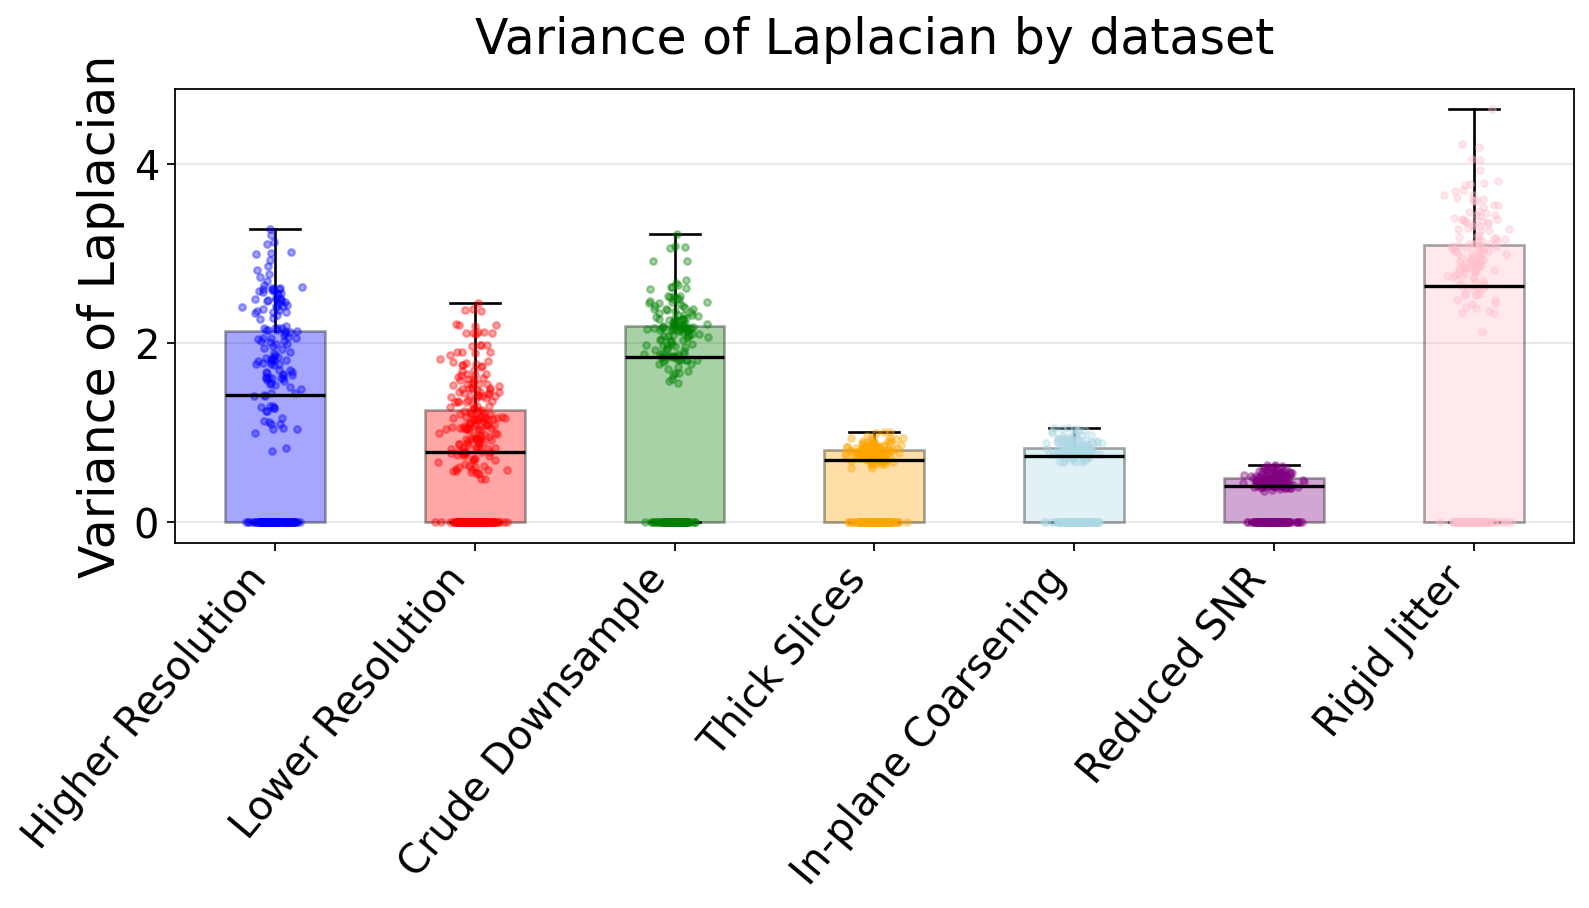

Saved _image_quality_eval_20251112_120355/box_lapvar_styled.png


In [46]:
import matplotlib.pyplot as plt
import numpy as np

def box_jitter_styled(df_use, metric, ylabel, fname):
    data = [df_use.loc[df_use["display"]==d, metric].dropna().values for d in order_present]

    fig = plt.figure(figsize=(10.5, 6.2), dpi=160)
    ax = fig.add_subplot(111)

    # colored boxes
    bp = ax.boxplot(
        data,
        labels=order_present,
        showfliers=False,
        patch_artist=True,  # <-- allows per-box facecolor
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )

    # set per-box face colors
    for patch, name in zip(bp['boxes'], order_present):
        patch.set_facecolor(color_map[name])
        patch.set_alpha(0.35)  # soft fill so medians stand out

    # jitter points, color-matched
    for i, name in enumerate(order_present, start=1):
        v = df_use.loc[df_use["display"]==name, metric].dropna().values
        if v.size == 0: 
            continue
        x = np.random.normal(i, 0.06, size=v.size)
        ax.plot(x, v, "o", markersize=3, alpha=0.35, color=color_map[name])

    ax.set_ylabel(ylabel, fontsize=22)
    ax.set_title(f"{ylabel} by dataset", fontsize=22, pad=16)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="both", labelsize=18)
    plt.xticks(rotation=50, ha="right")
    plt.tight_layout()
    p = OUT_ROOT/f"box_{fname}_styled.png"
    plt.savefig(p, dpi=220); plt.show()
    print("Saved", p)

# call for each metric
box_jitter_styled(df_disp, "fwhm_mm",       "FWHM blur (mm)", "fwhm")
box_jitter_styled(df_disp, "hi_freq_energy","High-freq energy fraction", "hfe")
box_jitter_styled(df_disp, "lap_var",       "Variance of Laplacian", "lapvar")


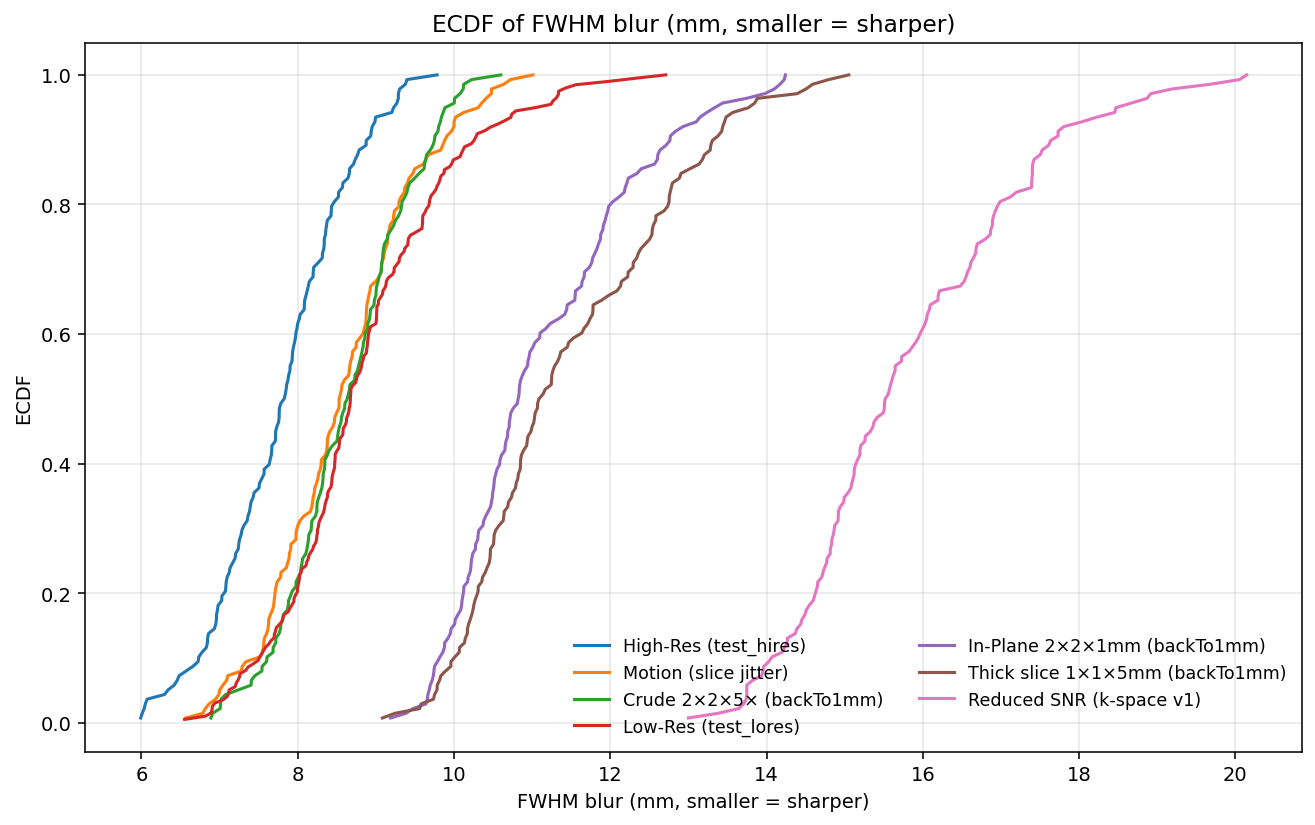

Saved _image_quality_eval_20251112_120355/ecdf_fwhm.png


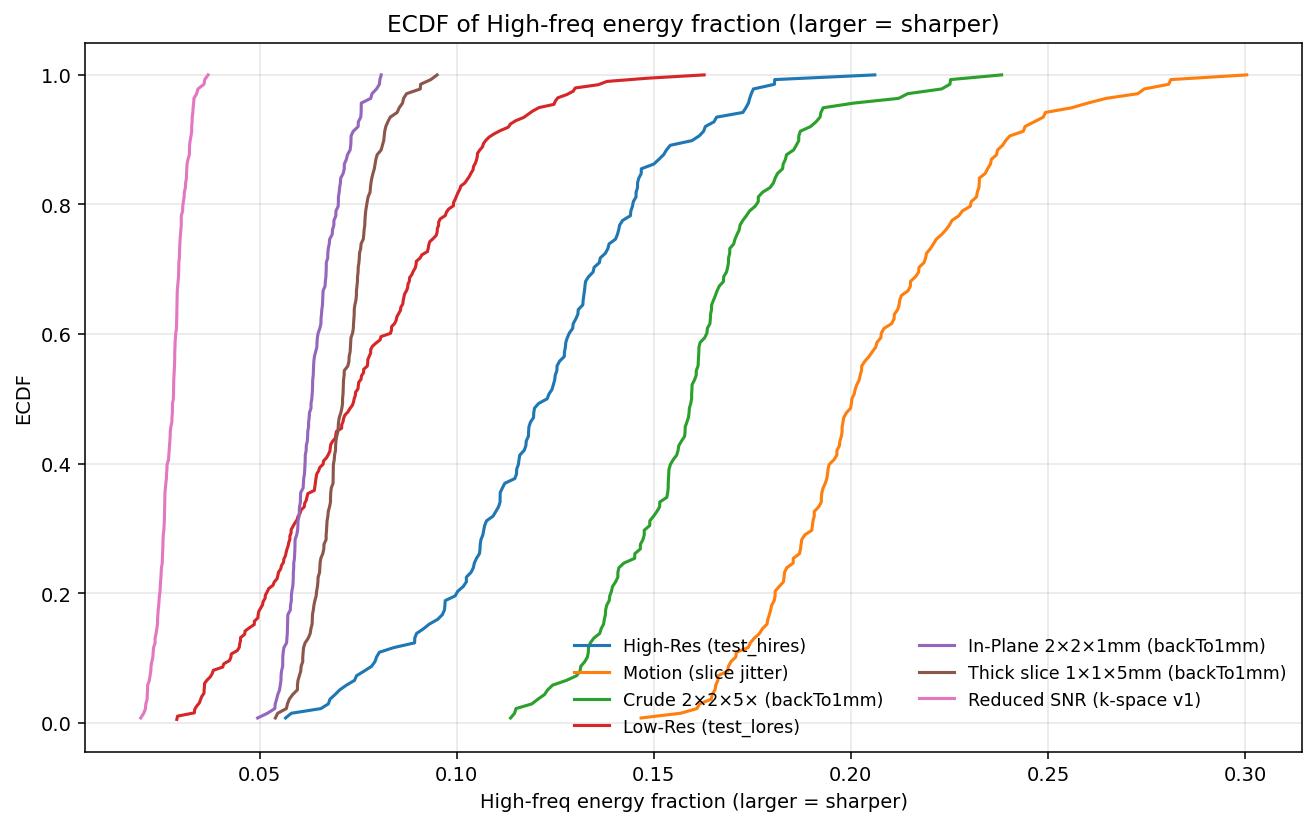

Saved _image_quality_eval_20251112_120355/ecdf_hfe.png


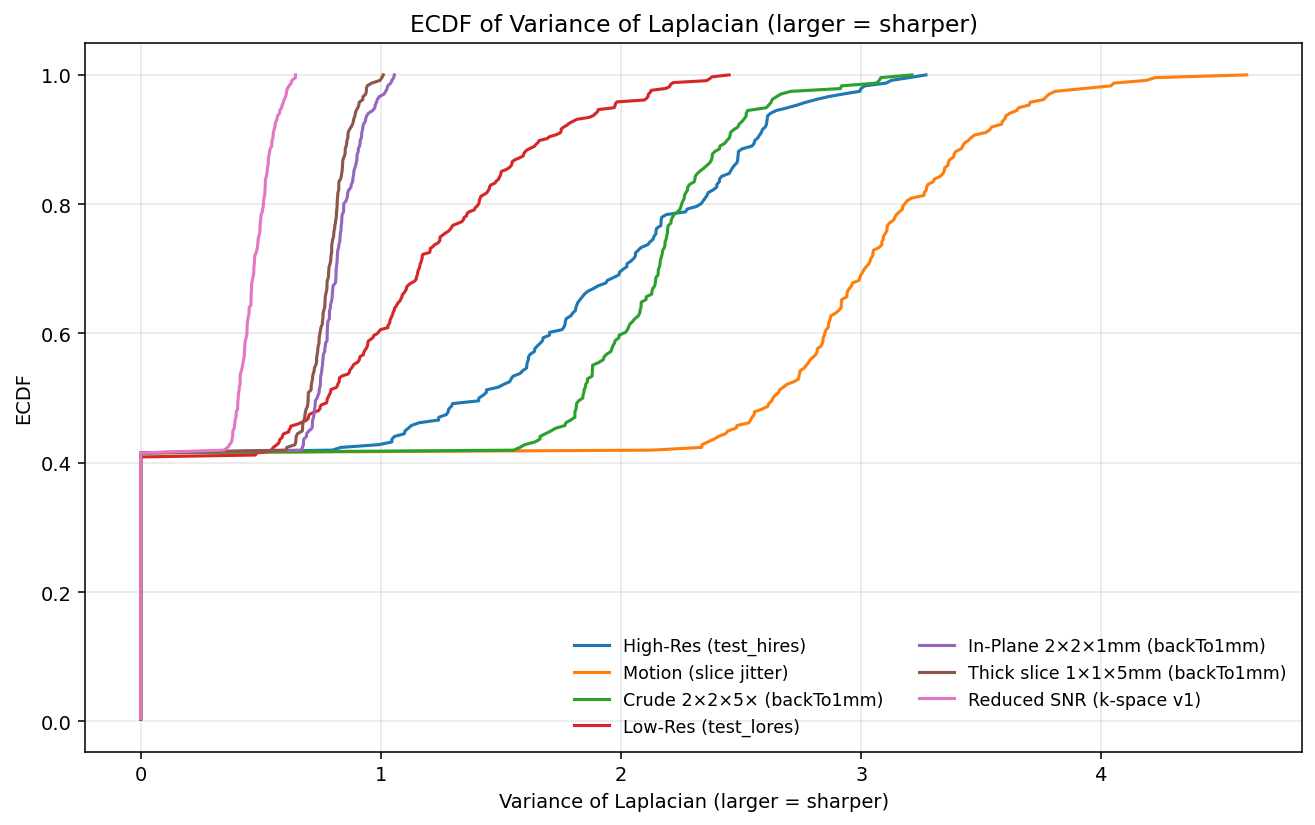

Saved _image_quality_eval_20251112_120355/ecdf_lapvar.png


In [11]:
def ecdf(a):
    a = np.asarray(a); a = a[~np.isnan(a)]
    if a.size==0: return np.array([]), np.array([])
    a = np.sort(a)
    y = np.arange(1, a.size+1)/a.size
    return a, y

def ecdf_plot(metric, xlabel, fname):
    fig = plt.figure(figsize=(9.5,6), dpi=140); ax = fig.add_subplot(111)
    for d in order:
        v = df[df["dataset"]==d][metric].values
        x, y = ecdf(v)
        if x.size==0: continue
        ax.plot(x, y, lw=1.6, label=d)
    ax.set_xlabel(xlabel); ax.set_ylabel("ECDF")
    ax.set_title(f"ECDF of {xlabel}")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, fontsize=9, ncol=2)
    plt.tight_layout()
    p = OUT_ROOT/f"ecdf_{fname}.png"
    plt.savefig(p, dpi=200); plt.show()
    print("Saved", p)

ecdf_plot("fwhm_mm", "FWHM blur (mm, smaller = sharper)", "fwhm")
ecdf_plot("hi_freq_energy", "High-freq energy fraction (larger = sharper)", "hfe")
ecdf_plot("lap_var", "Variance of Laplacian (larger = sharper)", "lapvar")


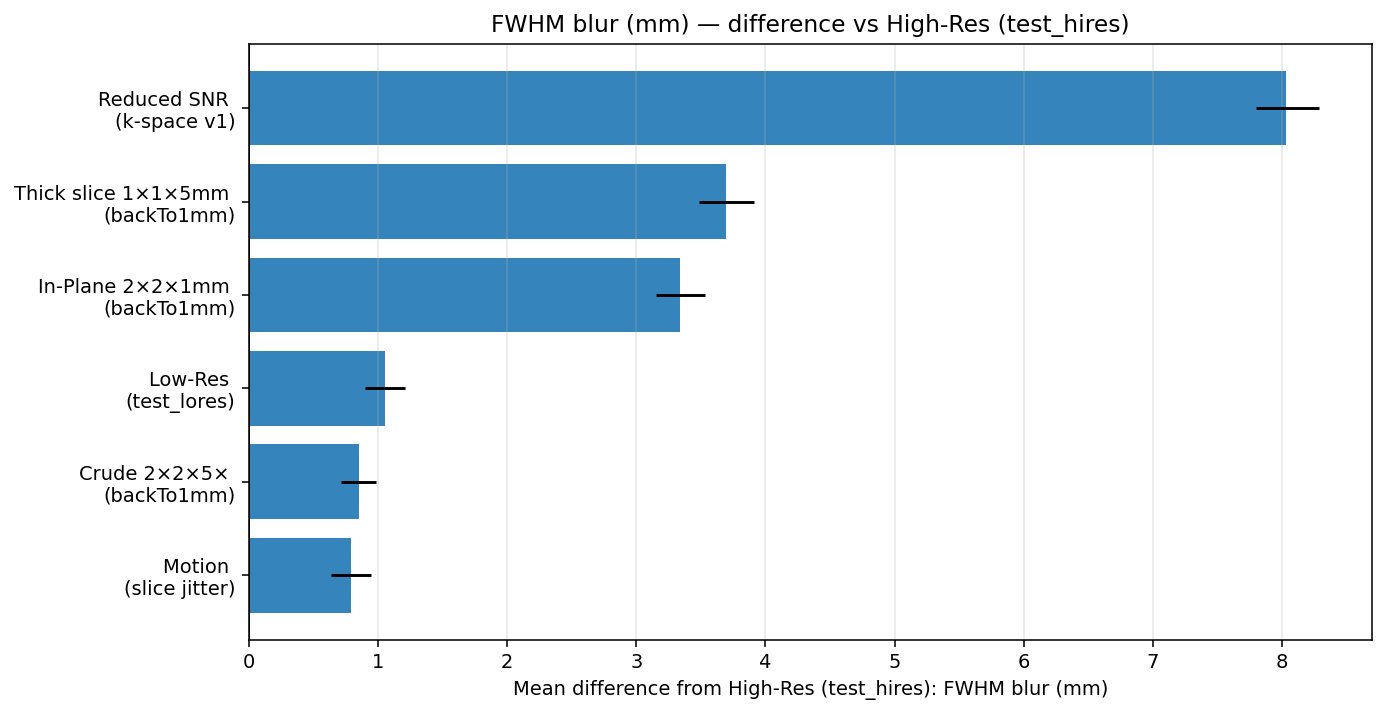

Saved _image_quality_eval_20251112_120355/diff_from_highres_fwhm.png


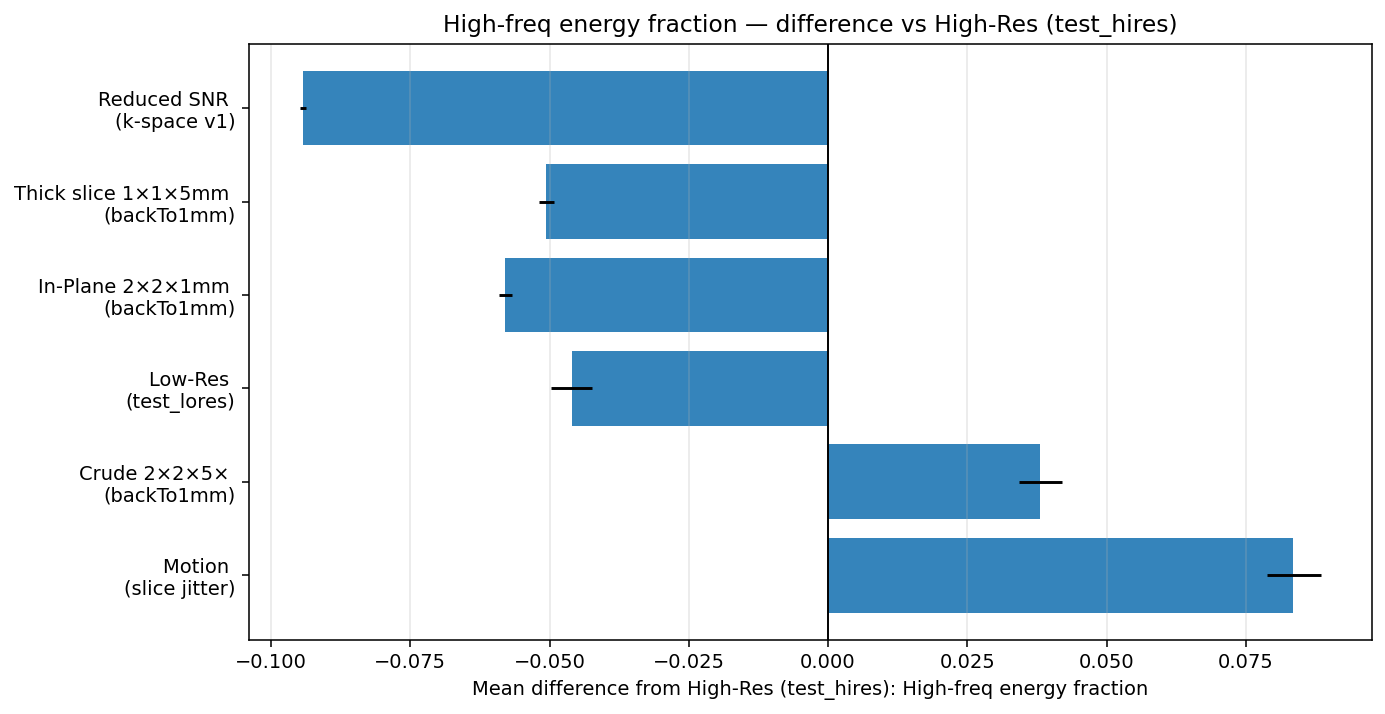

Saved _image_quality_eval_20251112_120355/diff_from_highres_hfe.png


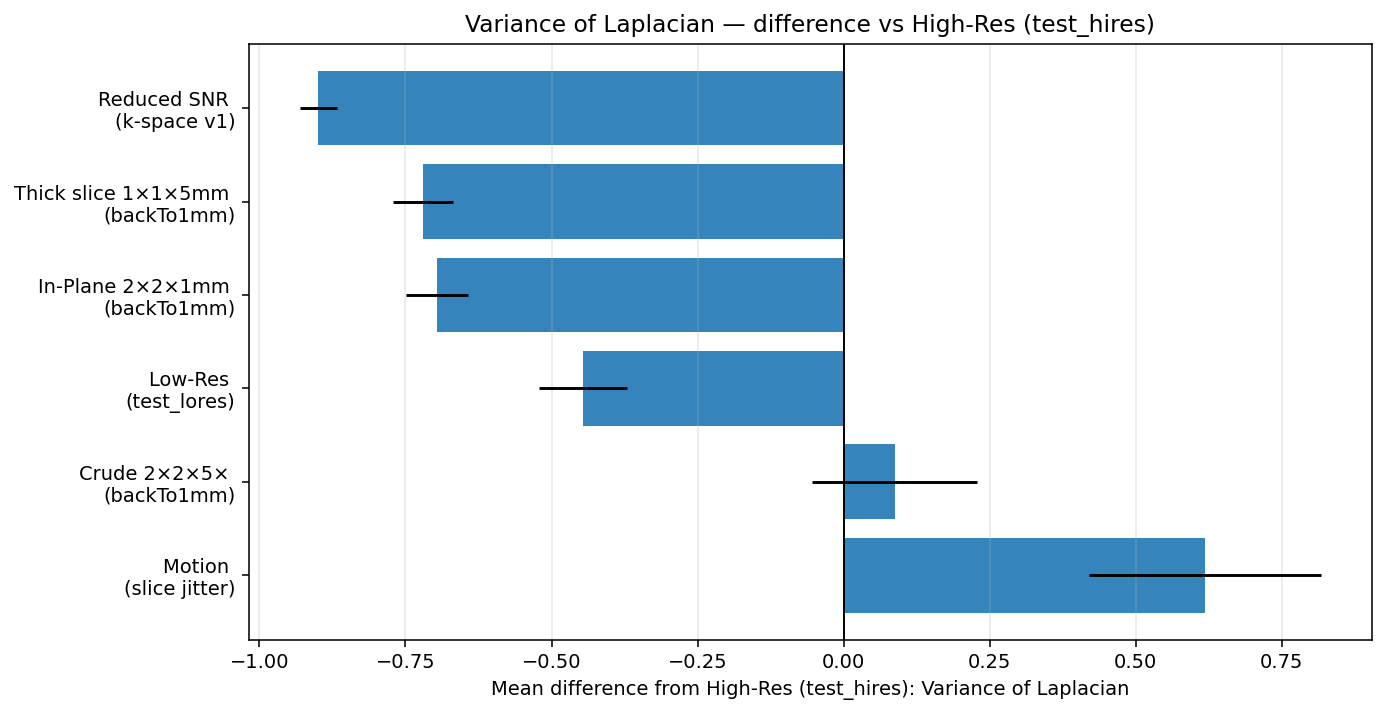

Saved _image_quality_eval_20251112_120355/diff_from_highres_lapvar.png


In [12]:
BASE = BASE_HI

def diff_from_base_plot(metric, ylabel, fname):
    base_vals = df[df["dataset"]==BASE][metric].values
    mu_base, _ = bootstrap_mean_ci(base_vals, nboot=4000, random_state=1)

    names, diffs, lo_ci, hi_ci = [], [], [], []
    for d in order:
        if d == BASE: continue
        v = df[df["dataset"]==d][metric].values
        mu, (lo, hi) = bootstrap_mean_ci(v, nboot=4000, random_state=2)
        names.append(d)
        diffs.append(mu - mu_base)
        lo_ci.append(lo - mu_base)
        hi_ci.append(hi - mu_base)

    fig = plt.figure(figsize=(10,5.2), dpi=140); ax = fig.add_subplot(111)
    y = np.arange(len(names))
    ax.barh(y, diffs, xerr=[np.array(diffs)-np.array(lo_ci), np.array(hi_ci)-np.array(diffs)], alpha=0.9)
    ax.set_yticks(y)
    ax.set_yticklabels([n.replace(" ("," \n(") for n in names])
    ax.axvline(0, color="k", lw=1)
    ax.set_xlabel(f"Mean difference from {BASE}: {ylabel}")
    ax.set_title(f"{ylabel} — difference vs {BASE}")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    p = OUT_ROOT/f"diff_from_highres_{fname}.png"
    plt.savefig(p, dpi=200); plt.show()
    print("Saved", p)

diff_from_base_plot("fwhm_mm", "FWHM blur (mm)", "fwhm")
diff_from_base_plot("hi_freq_energy", "High-freq energy fraction", "hfe")
diff_from_base_plot("lap_var", "Variance of Laplacian", "lapvar")


In [ ]:
def nice_pct(x):
    return "NA" if not np.isfinite(x) else f"{x:+.1f}%"

def assemble_report(df, stats_hi, stats_lo):
    lines = []
    lines.append("# Image Quality Metrics Report\n")
    lines.append(f"_Run: {RUN_TAG}_\n")
    lines.append("## Datasets\n")
    for k,v in DATASETS.items():
        lines.append(f"- **{k}**  \n  Path: `{v}`")
    lines.append("\n---\n")
    lines.append("## Percentile Summaries")
    lines.append("```\n" + summarize_df(df) + "\n```")

    def block(title, stats_df, base):
        lines.append(f"\n## Comparisons vs {base}\n")
        for metric, label in [("fwhm_mm","FWHM blur (mm, smaller=sharper)"),
                              ("hi_freq_energy","High-freq energy fraction (larger=sharper)"),
                              ("lap_var","Variance of Laplacian (larger=sharper)")]:
            lines.append(f"### {label}")
            sub = stats_df[stats_df["metric"]==metric].copy()
            if sub.empty:
                lines.append("_No data_\n"); continue
            # Order by percent change magnitude
            sub = sub.sort_values("pct_vs_base", ascending=False)
            for _, r in sub.iterrows():
                lines.append(
                    f"- **{r['dataset']}**: mean={r['mean_group']:.4f} "
                    f"(CI {r['ci_lo']:.4f}..{r['ci_hi']:.4f}) vs base {r['mean_base']:.4f}; "
                    f"Δ%={nice_pct(r['pct_vs_base'])}; "
                    f"Mann–Whitney U p={r['p']:.3g}; Cliff’s δ={r['cliffs_delta']:.3f}"
                )
            lines.append("")
    block("vs High-Res", stats_hi, "High-Res")
    block("vs Low-Res",  stats_lo, "Low-Res")

    return "\n".join(lines)

report_md = assemble_report(df, stats_vs_hi, stats_vs_lo)
(OUT_ROOT/"report.md").write_text(report_md)
print((OUT_ROOT/"report.md").resolve())

/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/_image_quality_eval_20251112_120355/report.md


##################################### IMAGE QUALITY TO MODEL RESULTS COMPARRISON #######################################

In [19]:
from pathlib import Path

CSV_ITEMS = [
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_hires_metrics_20251111_130301.csv"), "Higher Resolution"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_143340.csv"), "Lower Resolution"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_crude_metrics_20251111_155445.csv"), "Crude Downsample"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_161029.csv"), "Thick Slice"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_InPlane_metrics_20251111_163449.csv"), "In-Plane Coarsening"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_reducedsnr_metrics_20251111_181436.csv"), "Reduced SNR"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_reducedsnr_metrics_20251111_172142.csv"), "Rigid Jitter"),
]
print("CSV_ITEMS set with", len(CSV_ITEMS), "files.")


CSV_ITEMS set with 7 files.


In [25]:
import re
from pathlib import Path
import pandas as pd
import numpy as np

# 1) Load your image-quality CSV explicitly (your path)
IQ_CSV = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/_image_quality_eval_20251112_120355/effective_resolution_metrics_ALL.csv")
df = pd.read_csv(IQ_CSV)
print("Loaded IQ df:", IQ_CSV, "shape:", df.shape)

# 2) Canonical key builder used for BOTH sides
#    - Prefer "sub-XXX_ses-YYY" if present, else "sub-XXX" fallback
#    - Works with filenames like ".../sub-XXX_ses-YYY_T1w_MNI_norm.nii.gz"
SUB_SES = re.compile(r"(sub-[^_/]+_ses-[^_/]+)")
SUB_ONLY = re.compile(r"(sub-[^_/]+)")

def canonical_key_from_name(name: str) -> str:
    if not isinstance(name, str):
        return ""
    m = SUB_SES.search(name)
    if m:
        return m.group(1)
    m = SUB_ONLY.search(name)
    return m.group(1) if m else ""

def canonical_key_from_path(p: str) -> str:
    # Use filename (not stem) so we can match anywhere in the name
    fname = Path(p).name if isinstance(p, str) else ""
    return canonical_key_from_name(fname)

# 3) Build canonical keys on the performance side (perf_df) and IQ side (df)
#    perf_df comes from your prior Cell A
perf_df = perf_df.copy()
perf_df["key_raw"]   = perf_df["key"].astype(str)
# Try canonicalizing from 'key'; if empty, fall back to img_path
perf_df["key_can"]   = perf_df["key_raw"].apply(canonical_key_from_name)
fallback_mask        = perf_df["key_can"].eq("")
perf_df.loc[fallback_mask, "key_can"] = perf_df.loc[fallback_mask, "img_path"].apply(canonical_key_from_path)

# Image-quality side
q_df = df.copy()
q_df["key_can"]   = q_df["path"].apply(canonical_key_from_path)
q_df["iq_label"]  = q_df["dataset"].astype(str)

# 4) Redo join using canonical key
jq = perf_df.merge(
    q_df[["iq_label","key_can","fwhm_mm","hi_freq_energy","lap_var"]],
    on=["iq_label","key_can"],
    how="left"
)

print("perf_df shape:", perf_df.shape)
print("q_df shape:", q_df.shape)
print("joined jq shape:", jq.shape)

# 5) Diagnostics
missing = jq[jq[["fwhm_mm","hi_freq_energy","lap_var"]].isna().all(axis=1)]
print("Rows with missing quality metrics after CANONICAL join:", len(missing), "out of", len(jq))

# Peek a few missing rows to see what the eval key/path looks like
if len(missing) > 0:
    display(missing[["eval_label","iq_label","key","key_can","img_path"]].head(10))


Loaded IQ df: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/_image_quality_eval_20251112_120355/effective_resolution_metrics_ALL.csv shape: (1751, 5)
perf_df shape: (1026, 9)
q_df shape: (1751, 7)
joined jq shape: (1751, 12)
Rows with missing quality metrics after CANONICAL join: 0 out of 1751


In [26]:
# === B) QUALITY→PERFORMANCE EFFECT MEASURES ===================================
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, kendalltau, mstats

# ---- KNOBS (edit here) ----
QUALITY_METRICS  = ["fwhm_mm", "hi_freq_energy", "lap_var"]  # choose any subset/order
PERF_METRICS     = ["hard_dice", "hd", "assd"]               # which model outputs to compare
GROUP_BY_DATASET = True        # if True: compute per eval_label; if False: pool all rows
QPE_LO_Q         = 0.25        # bottom quartile cut
QPE_HI_Q         = 0.75        # top quartile cut
QPE_NORMALIZE    = "IQR"       # None | "IQR" | "MAD"  (scale Δ by performance spread)
SEED             = 7

def theil_sen_slope(x, y):
    """Return Theil–Sen slope (robust). Uses scipy mstats if available."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    m, b, lo, hi = mstats.theilslopes(y, x)  # y ~ m*x + b
    return float(m), (float(lo), float(hi))

def qpe_delta(df, q_col, y_col, lo_q=0.25, hi_q=0.75, normalize="IQR"):
    """Quartile Performance Effect: Δ median(y) [Q_hi - Q_lo], optional normalized."""
    d = df[[q_col, y_col]].dropna()
    if d.empty: 
        return np.nan, (np.nan, np.nan), np.nan, np.nan
    q_lo = d[q_col].quantile(lo_q); q_hi = d[q_col].quantile(hi_q)
    lo = d[d[q_col] <= q_lo][y_col].to_numpy()
    hi = d[d[q_col] >= q_hi][y_col].to_numpy()
    if lo.size < 3 or hi.size < 3:
        return np.nan, (np.nan, np.nan), np.nan, np.nan
    med_lo = np.median(lo); med_hi = np.median(hi)
    delta = med_hi - med_lo
    # CI via simple bootstrap
    rng = np.random.default_rng(SEED)
    boots = []
    for _ in range(2000):
        lo_b = rng.choice(lo, size=lo.size, replace=True)
        hi_b = rng.choice(hi, size=hi.size, replace=True)
        boots.append(np.median(hi_b) - np.median(lo_b))
    lo_ci, hi_ci = np.percentile(boots, [2.5, 97.5])

    # optional normalization to make it scale-free
    norm = 1.0
    y = d[y_col].to_numpy()
    if normalize == "IQR":
        iqr = np.subtract(*np.percentile(y, [75, 25]))
        norm = iqr if iqr > 0 else 1.0
    elif normalize == "MAD":
        mad = np.median(np.abs(y - np.median(y)))
        norm = mad if mad > 0 else 1.0
    delta_norm = delta / norm
    return float(delta), (float(lo_ci), float(hi_ci)), float(delta_norm), float(norm)

def summarize_effects(jq, quality_cols=QUALITY_METRICS, perf_cols=PERF_METRICS, by_dataset=GROUP_BY_DATASET):
    rows = []
    groups = [("ALL", jq)] if not by_dataset else [(g, d) for g,d in jq.groupby("eval_label", dropna=False)]
    for gname, sub in groups:
        for q_col in quality_cols:
            for y_col in perf_cols:
                d = sub[[q_col, y_col]].dropna()
                if d.shape[0] < 5:
                    rows.append(dict(group=gname, quality=q_col, perf=y_col,
                                     n=d.shape[0], rho=np.nan, rho_p=np.nan,
                                     tau=np.nan, tau_p=np.nan,
                                     ts_slope=np.nan, ts_lo=np.nan, ts_hi=np.nan,
                                     qpe=np.nan, qpe_lo=np.nan, qpe_hi=np.nan,
                                     qpe_norm=np.nan, norm_by=QPE_NORMALIZE))
                    continue
                rho, rp = spearmanr(d[q_col], d[y_col])
                tau, tp = kendalltau(d[q_col], d[y_col], nan_policy="omit")
                slope, (slo, shi) = theil_sen_slope(d[q_col], d[y_col])
                qpe, (qlo, qhi), qpe_norm, norm = qpe_delta(d, q_col, y_col, QPE_LO_Q, QPE_HI_Q, normalize=QPE_NORMALIZE)
                rows.append(dict(group=gname, quality=q_col, perf=y_col,
                                 n=d.shape[0], rho=rho, rho_p=rp, tau=tau, tau_p=tp,
                                 ts_slope=slope, ts_lo=slo, ts_hi=shi,
                                 qpe=qpe, qpe_lo=qlo, qpe_hi=qhi,
                                 qpe_norm=qpe_norm, norm_by=QPE_NORMALIZE, norm_val=norm))
    return pd.DataFrame(rows)

effects_df = summarize_effects(jq)
effects_df.sort_values(["perf","quality","group"]).head(12)


,group,quality,perf,n,rho,rho_p,tau,tau_p,ts_slope,ts_lo,ts_hi,qpe,qpe_lo,qpe_hi,qpe_norm,norm_by,norm_val
2,Crude Downsample,fwhm_mm,assd,125,0.112879,0.210077,0.074065,0.220601,0.189384,-0.118528,0.529464,0.682516,-0.791414,1.663088,0.255921,IQR,2.666894
11,Higher Resolution,fwhm_mm,assd,131,0.044750,0.611782,0.030887,0.600784,0.080711,-0.246033,0.400786,0.496184,-1.596530,1.400252,0.159703,IQR,3.106911
20,In-Plane Coarsening,fwhm_mm,assd,132,0.032272,0.713362,0.020588,0.726224,0.042693,-0.247527,0.314751,-0.120623,-2.199202,1.463425,-0.030347,IQR,3.974801
29,Lower Resolution,fwhm_mm,assd,183,0.141921,0.055310,0.095538,0.054826,0.167927,-0.004563,0.356506,0.374156,-0.422152,0.863676,0.147521,IQR,2.536292
38,Reduced SNR,fwhm_mm,assd,132,-0.156496,0.073139,-0.094842,0.106731,-0.176339,-0.519993,0.029139,-0.853636,-4.185795,1.312062,-0.242346,IQR,3.522390
47,Rigid Jitter,fwhm_mm,assd,133,0.037711,0.666500,0.026202,0.654608,0.163954,-0.570280,0.840431,0.163374,-3.520425,5.026446,0.022314,IQR,7.321566
56,Thick Slice,fwhm_mm,assd,131,0.044472,0.613994,0.030887,0.600784,0.083579,-0.318314,0.383572,0.972912,-2.879987,2.979018,0.178605,IQR,5.447282
5,Crude Downsample,hi_freq_energy,assd,125,-0.155963,0.082414,-0.099613,0.099461,-9.792390,-24.855564,1.803663,-0.856945,-2.672002,0.096877,-0.321327,IQR,2.666894
14,Higher Resolution,hi_freq_energy,assd,131,-0.114055,0.194580,-0.079977,0.175436,-7.426692,-21.069595,2.576864,-0.786677,-4.207880,0.398152,-0.253202,IQR,3.106911
23,In-Plane Coarsening,hi_freq_energy,assd,132,-0.126176,0.149406,-0.088365,0.132864,-33.172310,-87.240985,11.026302,-0.358852,-2.743175,1.292006,-0.090282,IQR,3.974801


In [27]:
# === C) COMPOSITE QUALITY INDEX (PCA-like z-score combo) =====================
# This squeezes your quality metrics into one index:
#   - Lower FWHM = sharper, so we NEGATE z(FWHM) before averaging
#   - Then average z-scores across metrics present per row

q_cols = [c for c in ["fwhm_mm","hi_freq_energy","lap_var"] if c in jq.columns]
jq_comp = jq.copy()
for c in q_cols:
    x = jq_comp[c].astype(float)
    mu, sd = np.nanmean(x), np.nanstd(x)
    jq_comp[c+"_z"] = (x - mu) / (sd if sd>0 else 1.0)

if "fwhm_mm_z" in jq_comp:
    jq_comp["fwhm_mm_z"] = -jq_comp["fwhm_mm_z"]  # lower FWHM = sharper ⇒ flip sign

z_cols = [c for c in [c+"_z" for c in q_cols] if c in jq_comp.columns]
jq_comp["quality_index"] = np.nanmean(jq_comp[z_cols].values, axis=1)

effects_comp = summarize_effects(
    jq_comp.rename(columns={"quality_index":"QI"}),
    quality_cols=["QI"],
    perf_cols=PERF_METRICS,
    by_dataset=GROUP_BY_DATASET
)
effects_comp.sort_values(["perf","group"])


,group,quality,perf,n,rho,rho_p,tau,tau_p,ts_slope,ts_lo,ts_hi,qpe,qpe_lo,qpe_hi,qpe_norm,norm_by,norm_val
2,Crude Downsample,QI,assd,220,0.036610,0.589122,0.028110,0.559809,0.041369,-0.119407,0.256363,-0.165394,-0.538336,0.702756,-0.072615,IQR,2.277681
5,Higher Resolution,QI,assd,227,0.055774,0.402968,0.038206,0.419708,0.073357,-0.111398,0.286445,0.289407,-0.344128,1.097549,0.112320,IQR,2.576635
8,In-Plane Coarsening,QI,assd,229,0.059197,0.372561,0.042972,0.362030,0.308200,-0.337320,1.118748,0.082177,-0.551239,1.174170,0.026609,IQR,3.088365
11,Lower Resolution,QI,assd,318,0.031831,0.571707,0.023226,0.560710,0.057850,-0.147145,0.289994,0.170201,-0.278277,0.520816,0.097280,IQR,1.749598
14,Reduced SNR,QI,assd,229,-0.019487,0.769290,-0.015199,0.747154,-0.083362,-0.942483,0.651955,-0.141998,-0.687902,0.574222,-0.047524,IQR,2.987895
17,Rigid Jitter,QI,assd,231,0.145307,0.027228,0.103051,0.028150,0.383203,0.024963,0.827305,2.258383,0.147185,4.363910,0.360329,IQR,6.267558
20,Thick Slice,QI,assd,227,0.071551,0.283067,0.054230,0.252066,0.556785,-0.337074,1.879499,0.336360,-1.309147,2.896320,0.078885,IQR,4.263934
0,Crude Downsample,QI,hard_dice,236,-0.157348,0.015543,-0.109313,0.018656,-0.028166,-0.054857,-0.002072,-0.065135,-0.146902,-0.003438,-0.228874,IQR,0.284589
3,Higher Resolution,QI,hard_dice,236,-0.095078,0.145348,-0.067493,0.145639,-0.013873,-0.040413,0.003804,-0.033229,-0.113525,0.038840,-0.119124,IQR,0.278947
6,In-Plane Coarsening,QI,hard_dice,236,-0.198226,0.002217,-0.140353,0.002505,-0.111390,-0.199574,-0.035219,-0.106181,-0.182266,-0.022247,-0.345314,IQR,0.307492


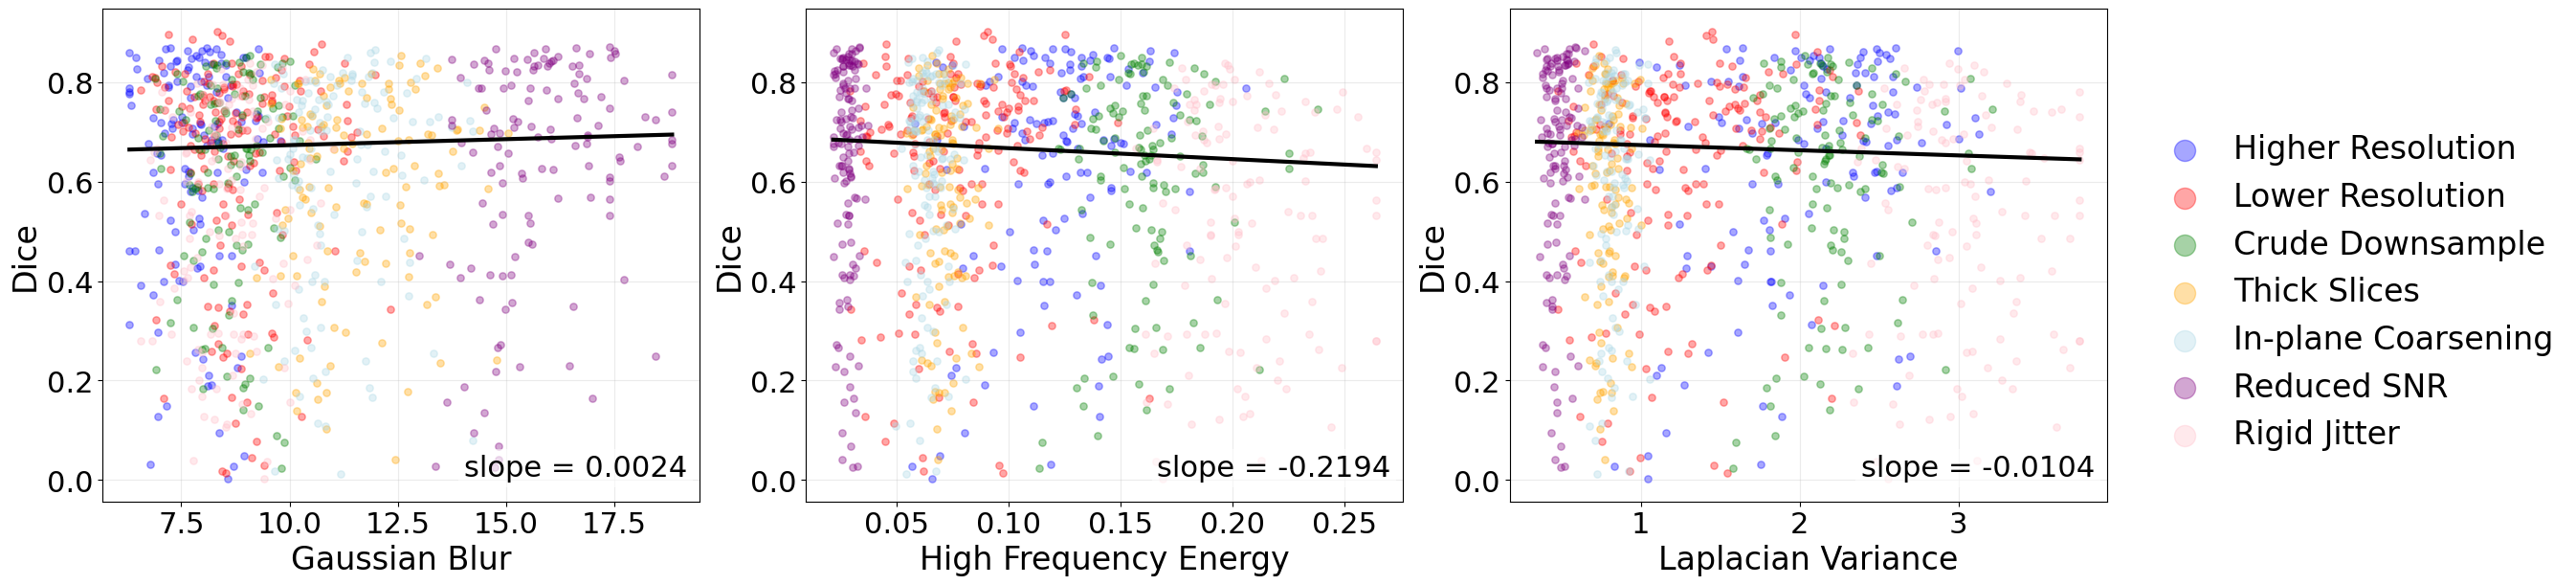

In [40]:
# ===== Scatter (Theil–Sen) for 3 quality metrics — reordered, retitled, big legend =====
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mstats

# -------- KNOBS --------
PERF_COL     = "hard_dice"     # change to 'hd' or 'assd' if desired
POINT_ALPHA  = 0.35
POINT_SIZE   = 28
FIGSIZE      = (22, 6)         # wide figure for 3 panels
DROP_X_ZERO  = True            # remove x == 0
DROP_Y_ZERO  = True            # remove y == 0

# Panel order & labels you requested
PANEL_SPECS = [
    ("fwhm_mm",       "Gaussian Blur"),        # left
    ("hi_freq_energy","High Frequency Energy"),# middle
    ("lap_var",       "Laplacian Variance"),   # right
]

# Your order + colors
order_display = [
    "Higher Resolution",
    "Lower Resolution",
    "Crude Downsample",
    "Thick Slices",
    "In-plane Coarsening",
    "Reduced SNR",
    "Rigid Jitter",
]
color_map = {
    "Higher Resolution"   : "blue",
    "Lower Resolution"    : "red",
    "Crude Downsample"    : "green",
    "Thick Slices"        : "orange",
    "In-plane Coarsening" : "lightblue",
    "Reduced SNR"         : "purple",
    "Rigid Jitter"        : "pink",
}

def display_label(name: str) -> str:
    s = (name or "").strip()
    s = s.replace("Thick Slice", "Thick Slices")
    s = s.replace("In-Plane Coarsening", "In-plane Coarsening")
    return s

# Big fonts everywhere
plt.rcParams.update({
    "font.size": 24,
    "axes.titlesize": 24,
    "axes.labelsize": 24,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 24,
})

def _scatter_panel(ax, data, xcol, xlabel, ycol="hard_dice"):
    d = data[[xcol, ycol, "eval_label"]].dropna()

    # remove exact zeros (both axes) if requested
    if DROP_X_ZERO:
        d = d[d[xcol] != 0]
    if DROP_Y_ZERO:
        d = d[d[ycol] != 0]

    # plot points in your specified dataset order
    present = {display_label(x) for x in d["eval_label"].unique()}
    groups  = [g for g in order_display if g in present]
    for g in groups:
        sub = d[d["eval_label"].map(display_label).eq(g)]
        if not sub.empty:
            ax.scatter(sub[xcol], sub[ycol],
                       s=POINT_SIZE, alpha=POINT_ALPHA,
                       color=color_map.get(g, "gray"),
                       label=g)

    # per-panel robust trend
    m, b, lo, hi = mstats.theilslopes(d[ycol], d[xcol])  # y ~ m*x + b
    xs = np.linspace(d[xcol].min(), d[xcol].max(), 100)
    ax.plot(xs, m*xs + b, lw=3, color="black")

    # annotate slope on the panel (so each panel shows its own slope)
    ax.text(0.98, 0.04, f"slope = {m:.4f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=22, bbox=dict(fc="white", ec="none", alpha=0.6))

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Dice")  # unified y-axis label
    ax.grid(True, alpha=0.25)

# Draw the 3-panel figure (no titles on top)
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, constrained_layout=True)
for ax, (xcol, xlabel) in zip(axes, PANEL_SPECS):
    _scatter_panel(ax, J, xcol, xlabel, ycol=PERF_COL)

# Single shared legend to the right, with big markers
handles, labels = axes[0].get_legend_handles_labels()
# Deduplicate while keeping your order_display
seen = set(); H, L = [], []
for ds in order_display:
    for h,l in zip(handles, labels):
        if l == ds and l not in seen:
            seen.add(l); H.append(h); L.append(l)
fig.legend(H, L, loc="center left", bbox_to_anchor=(1.01, 0.5),
           frameon=False, markerscale=3.0, scatterpoints=1, handlelength=1.5)

plt.show()


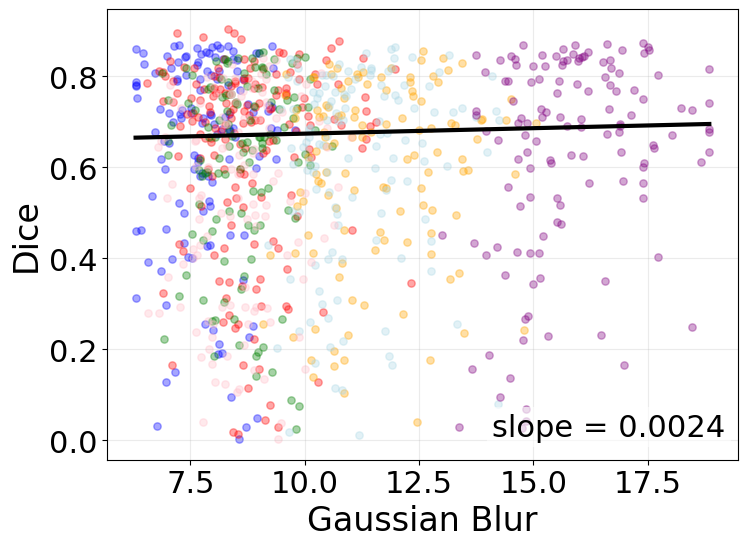

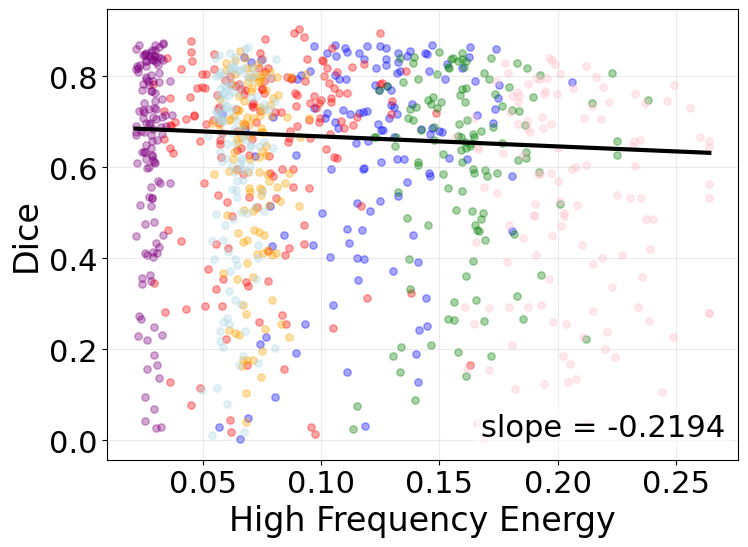

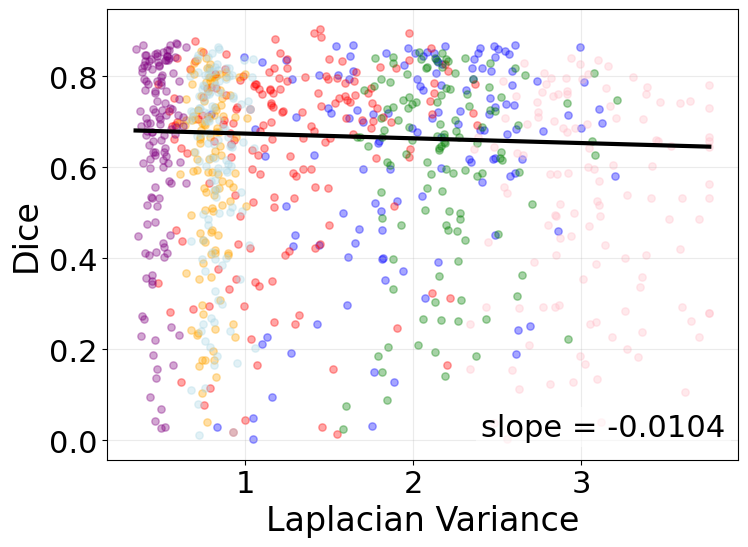

In [47]:
# ===== Scatter (Theil–Sen) for 3 quality metrics — reordered, retitled, NO LEGEND =====
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mstats

# -------- KNOBS --------
PERF_COL     = "hard_dice"     # change to 'hd' or 'assd' if desired
POINT_ALPHA  = 0.35
POINT_SIZE   = 28
FIGSIZE      = (8, 6)          # adjusted for single-panel figures (smaller width)
DROP_X_ZERO  = True            # remove x == 0
DROP_Y_ZERO  = True            # remove y == 0

# Panel order & labels you requested
PANEL_SPECS = [
    ("fwhm_mm",       "Gaussian Blur"),        # left
    ("hi_freq_energy","High Frequency Energy"),# middle
    ("lap_var",       "Laplacian Variance"),   # right
]

# Your order + colors
order_display = [
    "Higher Resolution",
    "Lower Resolution",
    "Crude Downsample",
    "Thick Slices",
    "In-plane Coarsening",
    "Reduced SNR",
    "Rigid Jitter",
]
color_map = {
    "Higher Resolution"   : "blue",
    "Lower Resolution"    : "red",
    "Crude Downsample"    : "green",
    "Thick Slices"        : "orange",
    "In-plane Coarsening" : "lightblue",
    "Reduced SNR"         : "purple",
    "Rigid Jitter"        : "pink",
}

def display_label(name: str) -> str:
    s = (name or "").strip()
    s = s.replace("Thick Slice", "Thick Slices")
    s = s.replace("In-Plane Coarsening", "In-plane Coarsening")
    return s

# Big fonts everywhere
plt.rcParams.update({
    "font.size": 24,
    "axes.titlesize": 24,
    "axes.labelsize": 24,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 24,
})

def _scatter_panel(ax, data, xcol, xlabel, ycol="hard_dice"):
    d = data[[xcol, ycol, "eval_label"]].dropna()

    # remove exact zeros (both axes) if requested
    if DROP_X_ZERO:
        d = d[d[xcol] != 0]
    if DROP_Y_ZERO:
        d = d[d[ycol] != 0]

    # plot points in your specified dataset order
    present = {display_label(x) for x in d["eval_label"].unique()}
    groups  = [g for g in order_display if g in present]
    for g in groups:
        sub = d[d["eval_label"].map(display_label).eq(g)]
        if not sub.empty:
            ax.scatter(sub[xcol], sub[ycol],
                       s=POINT_SIZE, alpha=POINT_ALPHA,
                       color=color_map.get(g, "gray"),
                       label=g)

    # per-panel robust trend
    m, b, lo, hi = mstats.theilslopes(d[ycol], d[xcol])  # y ~ m*x + b
    xs = np.linspace(d[xcol].min(), d[xcol].max(), 100)
    ax.plot(xs, m*xs + b, lw=3, color="black")

    # annotate slope on the panel (so each panel shows its own slope)
    ax.text(0.98, 0.04, f"slope = {m:.4f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=22, bbox=dict(fc="white", ec="none", alpha=0.6))

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Dice")  # unified y-axis label
    ax.grid(True, alpha=0.25)

# Create separate figures for each panel (no shared legend)
for xcol, xlabel in PANEL_SPECS:
    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
    _scatter_panel(ax, J, xcol, xlabel, ycol=PERF_COL)
    plt.tight_layout()
    plt.show()  # Or save each figure if needed, e.g., fig.savefig(f"{xlabel.replace(' ', '_')}.png", dpi=180)

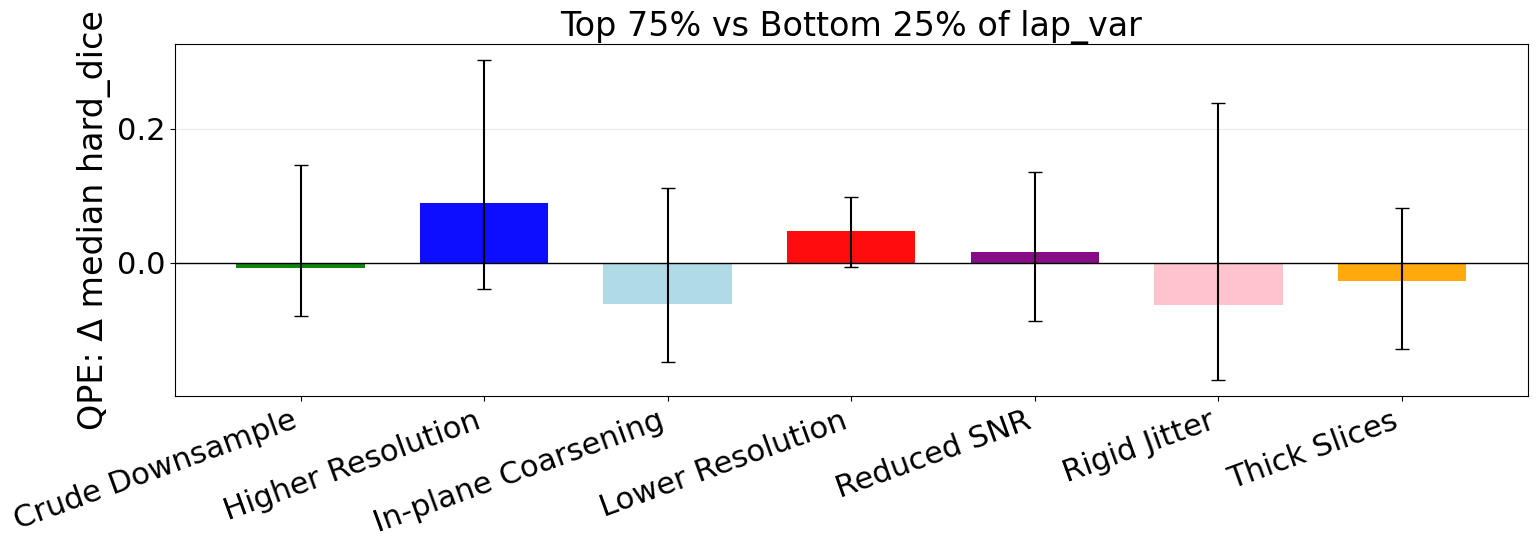

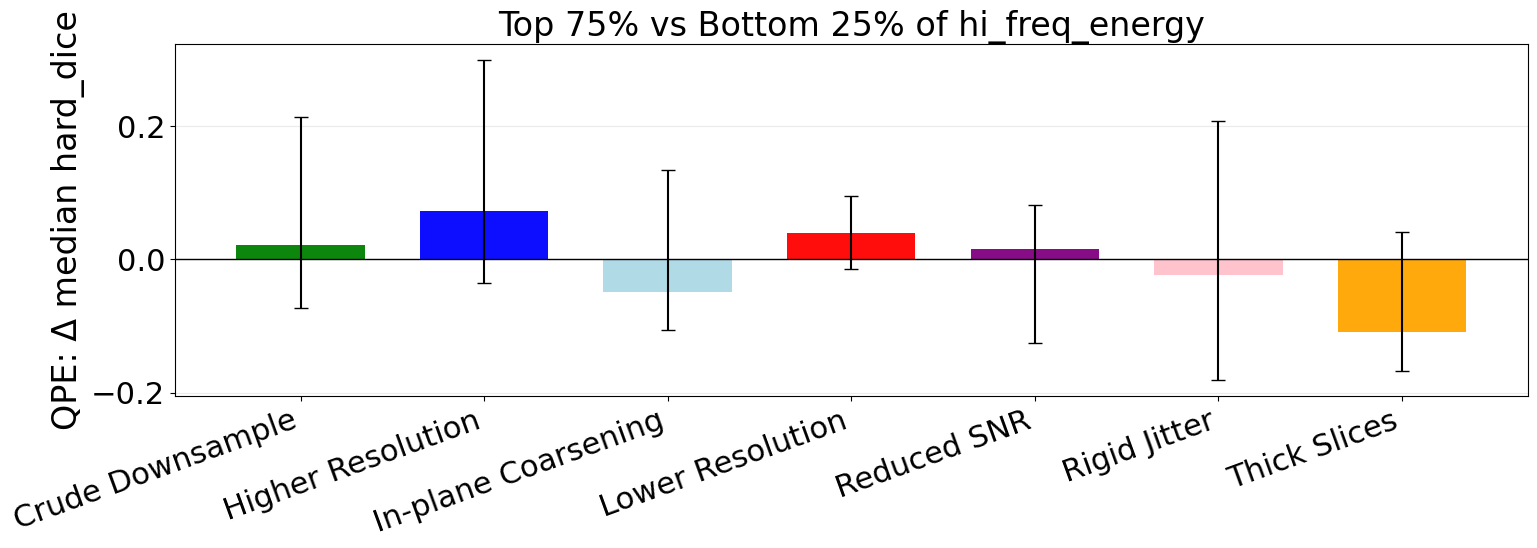

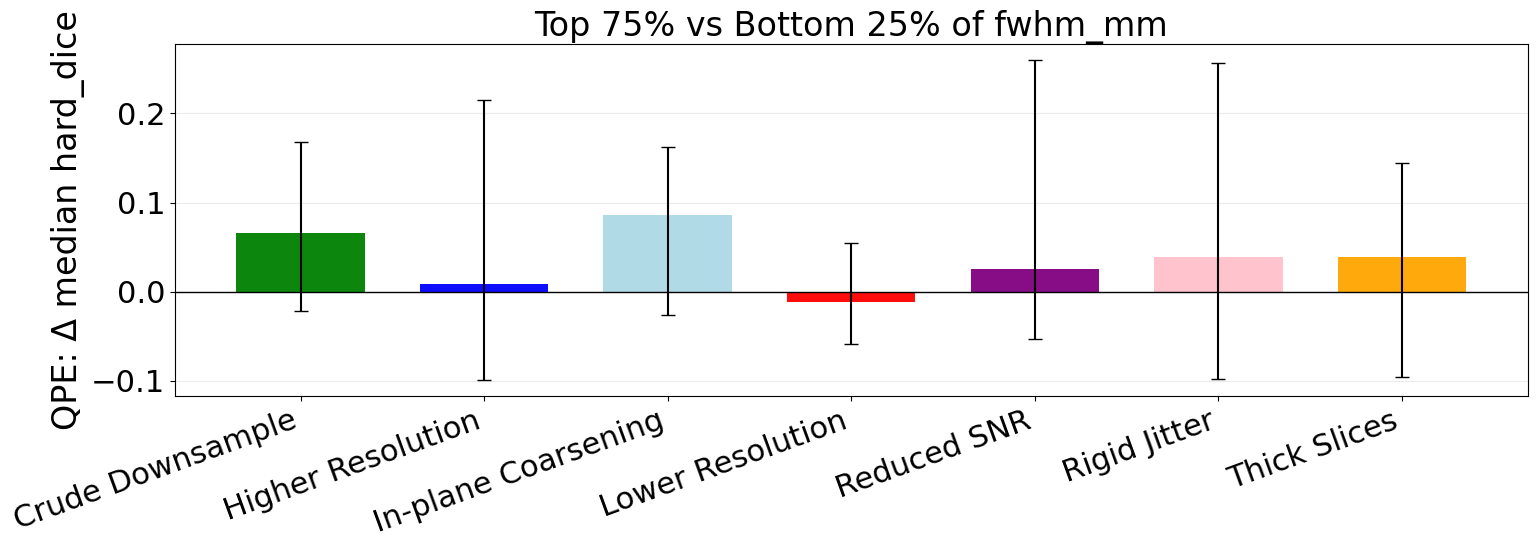

In [39]:
# ===== QPE bars for each quality metric (Top vs Bottom quartiles) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- KNOBS ----
PERF_COL = "hard_dice"    # 'hard_dice' | 'hd' | 'assd'
HI_Q = 0.75; LO_Q = 0.25  # quartiles used
BAR_WIDTH = 0.7
FIGSIZE = (16, 6)

def qpe_for_dataset(df, q_col, y_col, hi_q=0.75, lo_q=0.25, seed=7):
    rng = np.random.default_rng(seed)
    d = df[[q_col, y_col]].dropna()
    if len(d) < 8:
        return np.nan, np.nan, np.nan
    q_lo = d[q_col].quantile(lo_q); q_hi = d[q_col].quantile(hi_q)
    lo = d[d[q_col] <= q_lo][y_col].to_numpy()
    hi = d[d[q_col] >= q_hi][y_col].to_numpy()
    if len(lo) < 3 or len(hi) < 3:
        return np.nan, np.nan, np.nan
    delta = np.median(hi) - np.median(lo)
    boots = []
    for _ in range(2000):
        lo_b = rng.choice(lo, size=len(lo), replace=True)
        hi_b = rng.choice(hi, size=len(hi), replace=True)
        boots.append(np.median(hi_b) - np.median(lo_b))
    lo_ci, hi_ci = np.percentile(boots, [2.5, 97.5])
    return float(delta), float(lo_ci), float(hi_ci)

def plot_qpe_for_quality(J, q_col, y_col):
    # normalize label spelling for grouping
    J2 = J.copy()
    J2["disp_label"] = J2["eval_label"].map(display_label)

    rows = []
    for g in order_display:
        sub = J2[J2["disp_label"] == g][[q_col, y_col]]
        if sub.empty: 
            continue
        # drop zeros if requested (same as scatter)
        if DROP_X_ZERO:
            sub = sub[sub[q_col] != 0]
        if DROP_Y_ZERO:
            sub = sub[sub[y_col] != 0]
        qpe, lo, hi = qpe_for_dataset(sub, q_col, y_col, HI_Q, LO_Q)
        rows.append((g, qpe, lo, hi))
    T = pd.DataFrame(rows, columns=["dataset","qpe","lo","hi"]).dropna().sort_values("dataset")

    # plot
    plt.rcParams.update({"font.size": 24, "axes.titlesize": 24})
    fig, ax = plt.subplots(figsize=FIGSIZE)
    x = np.arange(len(T))
    colors = [color_map.get(ds, "gray") for ds in T["dataset"]]
    yerr = np.vstack([T["qpe"] - T["lo"], T["hi"] - T["qpe"]])

    ax.bar(x, T["qpe"], yerr=yerr, color=colors, edgecolor="none", width=BAR_WIDTH, capsize=5, alpha=0.95)
    ax.axhline(0, color="black", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(T["dataset"], rotation=20, ha="right")
    ax.set_ylabel(f"QPE: Δ median {y_col}")
    ax.set_title(f"Top {int(100*HI_Q)}% vs Bottom {int(100*LO_Q)}% of {q_col}")
    ax.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

# Make one QPE figure per quality metric
for q in ["lap_var", "hi_freq_energy", "fwhm_mm"]:
    plot_qpe_for_quality(J, q, PERF_COL)


In [29]:
# Coverage table: how many rows per dataset have each quality metric present
cov = (
    jq.assign(
        fwhm_ok = jq["fwhm_mm"].notna(),
        hfe_ok  = jq["hi_freq_energy"].notna(),
        lvar_ok = jq["lap_var"].notna(),
    )
    .groupby(["eval_label","iq_label"], dropna=False)[["fwhm_ok","hfe_ok","lvar_ok"]]
    .agg(["sum","count"])
)
display(cov)

# Rows still missing ALL quality metrics after join
missing_all = jq[jq[["fwhm_mm","hi_freq_energy","lap_var"]].isna().all(axis=1)]
print("Rows missing ALL quality metrics:", len(missing_all))
display(missing_all[["eval_label","iq_label","key","key_can","img_path"]].head(10))


fwhm_ok       hfe_ok  \
                                                        sum count    sum   
eval_label          iq_label                                               
Crude Downsample    Crude 2×2×5× (backTo1mm)            138   236    138   
Higher Resolution   High-Res (test_hires)               138   236    138   
In-Plane Coarsening In-Plane 2×2×1mm (backTo1mm)        138   236    138   
Lower Resolution    Low-Res (test_lores)                198   335    198   
Reduced SNR         Reduced SNR (k-space v1)            138   236    138   
Rigid Jitter        Motion (slice jitter)               138   236    138   
Thick Slice         Thick slice 1×1×5mm (backTo1mm)     138   236    138   

                                                          lvar_ok        
                                                    count     sum count  
eval_label          iq_label                                             
Crude Downsample    Crude 2×2×5× (backTo1mm)          236     236   236  
Higher Resolution   High-Res (test_hires)             236     236   236  
In-Plane Coarsening In-Plane 2×2×1mm (backTo1mm)      236     236   236  
Lower Resolution    Low-Res (test_lores)              335     335   335  
Reduced SNR         Reduced SNR (k-space v1)          236     236   236  
Rigid Jitter        Motion (slice jitter)             236     236   236  
Thick Slice         Thick slice 1×1×5mm (backTo1mm)   236     236   236

Rows missing ALL quality metrics: 0


,eval_label,iq_label,key,key_can,img_path


In [30]:
import numpy as np
import pandas as pd

# Copy to avoid mutating original
J = jq.copy()

# 1) Drop rows with missing performance metric we care about
#    (change 'hard_dice' to 'hd'/'assd' as needed)
J = J[J["hard_dice"].notna()]

# 2) For quality metrics, keep rows where at least ONE metric is present
J = J[J[["fwhm_mm","hi_freq_energy","lap_var"]].notna().any(axis=1)]

# 3) Winsorize extreme outliers lightly (avoid infinity leverage in Theil–Sen)
def winsorize_series(s, p=0.005):
    x = s.to_numpy().astype(float)
    lo, hi = np.nanpercentile(x, [100*p, 100*(1-p)])
    return s.clip(lower=lo, upper=hi)

for col in ["fwhm_mm","hi_freq_energy","lap_var"]:
    if col in J:
        J[col] = winsorize_series(J[col])

# 4) Optional: remove exact zeros for lap_var if you suspect they’re artefacts
MIN_LVAR = 1e-8  # <-- dial; set None to disable
if MIN_LVAR is not None and "lap_var" in J:
    J.loc[J["lap_var"] < MIN_LVAR, "lap_var"] = np.nan

# 5) Final dropna per plot later (scatter functions already do dropna on x,y)
print("Rows kept after cleaning:", len(J))


Rows kept after cleaning: 1751


/tmp/ipykernel_2056658/2165929965.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.9,0.95])


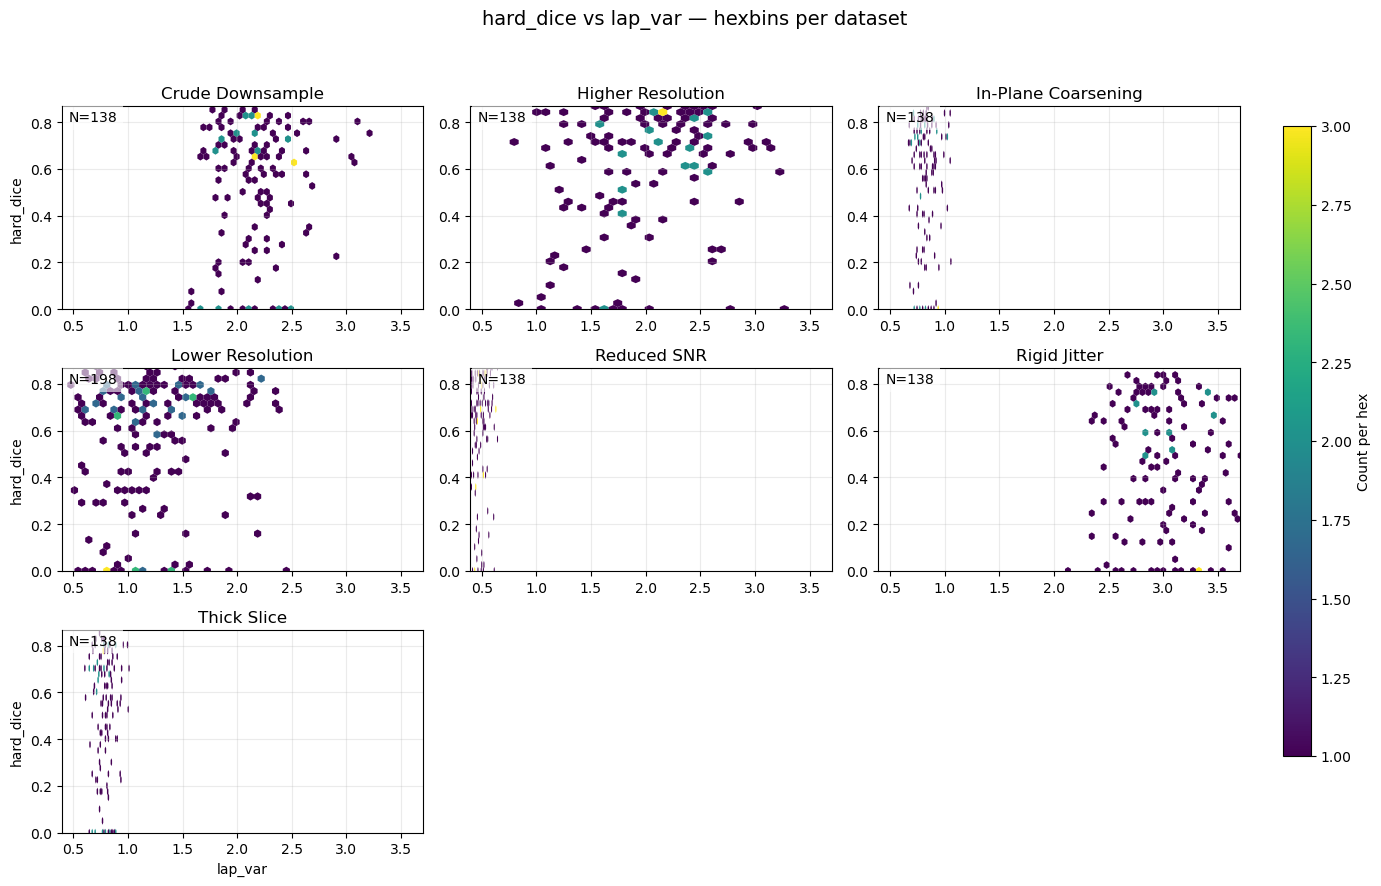

In [32]:
# === P1) FACETED HEXBIN: quality vs performance (per dataset) ===============
import numpy as np, matplotlib.pyplot as plt

# ---- KNOBS ----
X_COL = "lap_var"           # "lap_var" | "hi_freq_energy" | "fwhm_mm" | "QI" (if built)
Y_COL = "hard_dice"         # "hard_dice" | "hd" | "assd"
GRIDSIZE = 30               # hex resolution (bigger = finer)
CMAP = "viridis"            # any matplotlib cmap
FIG_COLS = 3                # number of facets per row
FIG_W, FIG_H = 14, 9        # figure size
TITLE = f"{Y_COL} vs {X_COL} — hexbins per dataset"
SHARE_AXES = True           # share x/y limits across facets
ANNOT_N = True              # annotate N in each facet

D = J[[X_COL, Y_COL, "eval_label"]].dropna()
groups = sorted(D["eval_label"].unique())
n = len(groups)
rows = int(np.ceil(n / FIG_COLS))

# global limits for shared axes
if SHARE_AXES:
    xlim = (D[X_COL].quantile(0.01), D[X_COL].quantile(0.99))
    ylim = (D[Y_COL].quantile(0.01), D[Y_COL].quantile(0.99))
else:
    xlim = ylim = None

fig, axes = plt.subplots(rows, FIG_COLS, figsize=(FIG_W, FIG_H), squeeze=False)
ax_flat = axes.ravel()

for ax, g in zip(ax_flat, groups):
    sub = D[D["eval_label"] == g]
    hb = ax.hexbin(sub[X_COL], sub[Y_COL],
                   gridsize=GRIDSIZE, cmap=CMAP, mincnt=1, linewidths=0)
    if SHARE_AXES:
        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_title(g, fontsize=12)
    ax.grid(True, alpha=0.25)
    if ANNOT_N:
        ax.text(0.02, 0.98, f"N={len(sub)}", transform=ax.transAxes,
                va="top", ha="left", fontsize=10,
                bbox=dict(fc="white", ec="none", alpha=0.6))
# empty panels (if any)
for ax in ax_flat[len(groups):]:
    ax.axis("off")

# one colorbar for the whole grid
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cb = fig.colorbar(hb, cax=cax)
cb.set_label("Count per hex")

fig.suptitle(TITLE, fontsize=14)
for ax in axes[-1]:
    ax.set_xlabel(X_COL)
for r in axes:
    r[0].set_ylabel(Y_COL)

plt.tight_layout(rect=[0,0,0.9,0.95])
plt.show()


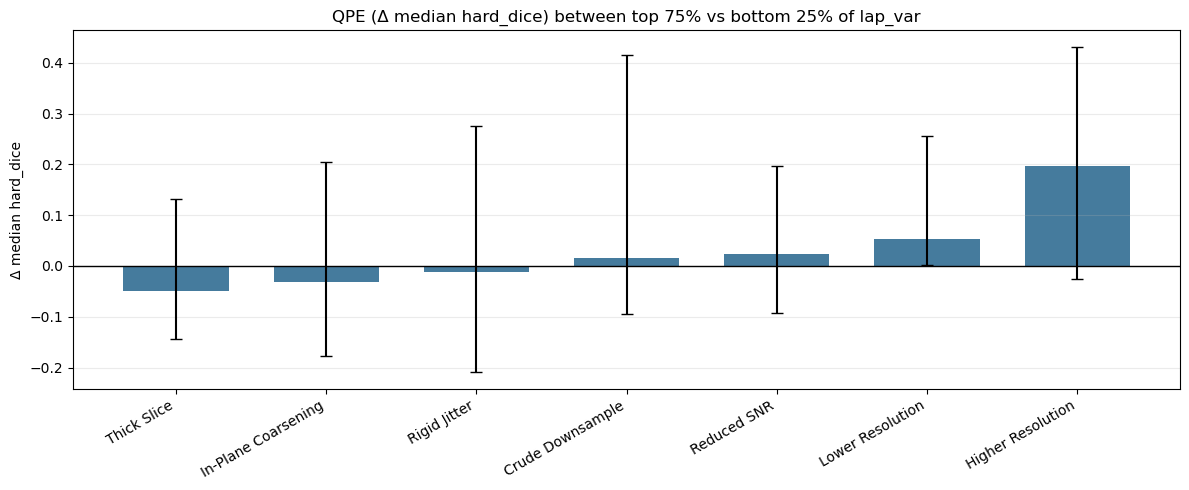

In [33]:
# === P2) QPE BAR PLOT (sorted) ==============================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ---- KNOBS ----
Q_COL = "lap_var"    # quality metric
Y_COL = "hard_dice"  # performance
HI_Q, LO_Q = 0.75, 0.25
WIDTH = 0.7
BAR_COLOR = "#457b9d"
EDGE = "none"
FIGSIZE = (12, 5)
TITLE = f"QPE (Δ median {Y_COL}) between top {int(HI_Q*100)}% vs bottom {int(LO_Q*100)}% of {Q_COL}"

def qpe_delta_df(df, q_col, y_col, lo_q=0.25, hi_q=0.75, seed=7):
    out = []
    rng = np.random.default_rng(seed)
    for g, sub in df.groupby("eval_label"):
        d = sub[[q_col, y_col]].dropna()
        if len(d) < 8:
            out.append((g, np.nan, np.nan, np.nan)); continue
        q_lo = d[q_col].quantile(lo_q); q_hi = d[q_col].quantile(hi_q)
        lo = d[d[q_col] <= q_lo][y_col].to_numpy()
        hi = d[d[q_col] >= q_hi][y_col].to_numpy()
        if len(lo) < 3 or len(hi) < 3:
            out.append((g, np.nan, np.nan, np.nan)); continue
        delta = np.median(hi) - np.median(lo)
        boots = []
        for _ in range(2000):
            lo_b = rng.choice(lo, size=len(lo), replace=True)
            hi_b = rng.choice(hi, size=len(hi), replace=True)
            boots.append(np.median(hi_b) - np.median(lo_b))
        lo_ci, hi_ci = np.percentile(boots, [2.5, 97.5])
        out.append((g, delta, lo_ci, hi_ci))
    T = pd.DataFrame(out, columns=["dataset","qpe","lo","hi"]).dropna()
    return T.sort_values("qpe")

T = qpe_delta_df(J, Q_COL, Y_COL, LO_Q, HI_Q)

fig, ax = plt.subplots(figsize=FIGSIZE)
x = np.arange(len(T))
ax.bar(x, T["qpe"], yerr=[T["qpe"]-T["lo"], T["hi"]-T["qpe"]],
       color=BAR_COLOR, edgecolor=EDGE, capsize=4, width=WIDTH)
ax.axhline(0, color="black", lw=1)
ax.set_xticks(x); ax.set_xticklabels(T["dataset"], rotation=30, ha="right")
ax.set_ylabel(f"Δ median {Y_COL}")
ax.set_title(TITLE)
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout(); plt.show()
